# Chapter 35. The Math Under the Models

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch35-the-math-under-the-models.md`.

# Chapter 35. The Math Under the Models

*Part 4 — Machine Learning & Data Science*

> **Chapter at a glance**
>
> **You will learn to:** treat each row of a dataset as a vector and measure distance and similarity between rows · multiply a matrix of features by a vector of weights to predict every row at once · read a derivative and a gradient as "which way is downhill, and how steep" · run gradient descent by hand for three steps, then in NumPy, and spot a bad learning rate or unscaled feature from the loss alone · describe data with the Bernoulli, binomial, Poisson, and normal distributions, and say when a distribution doesn't fit · find a maximum likelihood estimate and connect it to the loss a classifier minimizes · calculate entropy, cross-entropy, and log loss, and use them to judge a probability score · work through principal component analysis (PCA) on a small example by hand, then on all Riverstone customers.
>
> **Before you start:** Chapter 4 (percentages, averages), Chapter 13 (the one-year database), Chapters 17 and 18 (Python, pandas, and the NumPy basics in section 18.1), Chapter 21 (mean, standard deviation, z-scores, probability, and the normal, binomial, and Poisson distributions with `scipy.stats`), Chapter 22, section 22.10 (fitting a straight line), and Chapter 31, section 31.0 (natural logarithms). No calculus or linear algebra is assumed, and section 35.8 adds the two facts about logarithms this chapter needs beyond section 31.0.
>
> **Time needed:** 14–17 hours of reading and practice, spread over two to three weeks, in four sittings: **A**, sections 35.1–35.3 (vectors, dot products, matrices), about 3 hours; **B**, sections 35.4–35.6 (loss, derivatives, gradient descent), about 4 hours; **C**, sections 35.7–35.9 (distributions, likelihood, logarithms, entropy, log loss), about 4 hours; **D**, sections 35.10–35.11 (PCA), about 3 hours; then the project. Sittings B and C end with a ten-minute checkpoint. Do the hand calculations with a pen before you run the code.
>
> **Tools:** Python in the virtual environment from Chapter 17, with NumPy, pandas, and matplotlib (installed in Chapter 18) and scipy (Chapter 21). You'll install **scikit-learn** in section 35.9, where it's first used, for two cross-checks. A calculator or spreadsheet for the hand work.
>
> **Practice data:** three small files built from the one-year Riverstone database (`riverstone_2025`) by `companion/ch35/make_ch35_data.py`: `customers_2025.csv`, `orders_2025.csv`, and `leads_2025.csv`. If the three files aren't in your copy of the folder, run `python make_ch35_data.py` there once. Every number in this chapter was calculated, and every output shown is real.

---

## Why this matters

You can train a machine learning model in three lines of Python. The trouble starts when it misbehaves, and it will:

- The model's error stops falling after a few rounds of training, or shoots up to a number with 80 digits.
- A colleague's clustering puts every customer in the same group, because one column is measured in rupees and the rest in counts.
- A vendor tells your sales head their lead score is "91% accurate" (it gets 91 of every 100 leads right), and nobody in the room knows whether that is good.
- Two models have the same accuracy, and someone asks which to trust.
- An interviewer asks, *"Why do we use log loss for logistic regression and not squared error?"*

Each of these is a math question in disguise. You don't need proofs to answer them. You need six ideas, understood well enough to calculate by hand: **vectors**, **matrices**, **gradients**, **probability distributions**, **likelihood**, and **entropy**. This chapter teaches those six with Riverstone's numbers, one worked calculation at a time. After it, every algorithm in Chapters 36 to 43 will look like a variation on one theme, and you'll be able to reason about a model instead of guessing.

---

## In plain English

**Think of a tailor who makes uniforms for Riverstone's customers.**

The tailor writes each customer's measurements on a card: chest, waist, sleeve, height. That list of numbers, always in the same order, is a **vector**. A drawer full of cards, one per customer, is a **matrix**. To compare two customers, the tailor lines their cards up side by side and sees how closely the measurements agree; that comparison is a **dot product**.

The tailor cuts a pattern, the customer tries it on, and the tailor notes how badly it fits: one number for "how wrong". That number is the **loss**. The tailor doesn't start over each time. They ask, *"If I let out the waist a little, does the fit get better or worse, and how quickly?"* That question is the **derivative**, and asking it for every seam at once gives the **gradient**. Adjusting every seam a small amount in the better direction, trying it on again, and repeating is **gradient descent**. Adjust too boldly and the jacket swings from too tight to too loose and never fits; that's a **learning rate** set too high.

When a new customer walks in and the tailor has no card yet, they guess the size from experience of who usually walks in. That's a **probability distribution**. Choosing the guess that makes the customers they've already seen least surprising is **maximum likelihood**, and the tailor's surprise when a guess is wrong is **cross-entropy**.

Finally, the tailor notices that chest, waist, and sleeve mostly move together, so a single "size" (S, M, L) captures most of what the card says. Finding that one summary direction is **principal component analysis**.

Vectors, matrices, gradients, distributions, likelihood, entropy, PCA: that's the whole chapter.

---

## 35.1 Vectors: every customer is a point

### A row is a list of numbers

*"How do I describe a customer so a computer can compare them with another?"* Pick some measurements and write them in a fixed order. Here are two Riverstone customers from 2025, described by the number of orders they placed and their net revenue in ₹ lakh (₹1,00,000):

| Customer | Orders | Revenue (₹ lakh) |
|---|---|---|
| Sharma Hardware | 16 | 5.03 |
| Metro Mart | 16 | 3.29 |

As vectors: **Sharma = [16, 5.03]** and **Metro = [16, 3.29]**. A **vector** is an ordered list of numbers. Each number is a **component**, and the number of components is the vector's **dimension**. These are 2-dimensional vectors, so you can draw each customer as a point on a chart with orders across and revenue up. A customer described by seven measurements is a point in 7-dimensional space. You can't draw that, but the arithmetic is the same.

In machine learning, each component is usually called a **feature**. A model never sees "Sharma Hardware"; it sees the vector.

### Distance between two customers

*"How different are Sharma Hardware and Metro Mart?"* Treat them as points and measure the straight-line distance, the **Euclidean distance**. Subtract component by component, square, add, and take the square root:

> distance = √((16 − 16)² + (5.03 − 3.29)²) = √(0 + 1.74²) = √3.0276 = **1.74**

The **length** (or **norm**) of a single vector is its distance from zero. For Sharma: √(16² + 5.03²) = √(256 + 25.30) = √281.30 = **16.77**.

NumPy (Chapter 18, section 18.1) does this arithmetic on whole arrays at once. Here is the same calculation:

In [1]:
import numpy as np
import pandas as pd

sharma = np.array([16, 5.03])
metro = np.array([16, 3.29])

difference = sharma - metro
distance = np.sqrt(np.sum(difference ** 2))
print("difference:", difference)
print("distance:  ", round(distance, 2))
print("same with np.linalg.norm:", round(np.linalg.norm(sharma - metro), 2))
print("length of sharma:", round(np.linalg.norm(sharma), 2))

difference: [0.   1.74]
distance:   1.74
same with np.linalg.norm: 1.74
length of sharma: 16.77


**How it works:**

- `np.array([16, 5.03])` makes a vector, exactly as section 18.1 made an array of quantities. Arithmetic works position by position, as it did there: `sharma - metro` subtracts 16 from 16 and 3.29 from 5.03 in one step, with no loop. (`0.` is how NumPy prints the float 0.0.)
- `difference ** 2` squares each component; `np.sum` adds them; `np.sqrt` takes the square root. That's the formula, line for line.
- `np.linalg.norm` does the same calculation in one call (`linalg` is NumPy's linear algebra toolbox, and "norm" is the length). Use it in real work, but know what it does.
- `round(distance, 2)` rounds to two decimals for printing, as in Chapter 17.

> **Watch out: units decide distance.** Measure revenue in rupees instead of lakh and Sharma becomes [16, 5,02,775]. Now a difference of 1 order counts as much as a difference of ₹1, so distance is driven almost entirely by revenue, and orders might as well not exist. Any method built on distance or spread (k-nearest neighbors, k-means clustering, PCA) is affected. The fix is **scaling**: put every feature on a comparable scale before measuring distance. Section 35.10 shows the damage with real numbers, and Chapter 36 turns scaling into a standard step.

### The whole customer table as vectors

Load the practice file and look at a few customers. Each row is a vector of features:

In [2]:
customers = pd.read_csv("customers_2025.csv")
print(len(customers), "customers who ordered in 2025")
view = customers[["customer_name", "orders", "revenue", "storage_share",
                  "kitchen_share", "industrial_share", "furniture_share"]]
view.columns = ["customer", "orders", "revenue", "storage", "kitchen", "industrial", "furniture"]
print(view.head(5).to_string(index=False))

23 customers who ordered in 2025
         customer  orders  revenue  storage  kitchen  industrial  furniture
  Sharma Hardware      16   502775    0.656    0.310       0.000      0.034
Patel Kitchenware       7   174148    0.414    0.492       0.000      0.094
Green Leaf Hotels      17   331389    0.386    0.614       0.000      0.000
    Coastal Foods      12   323631    0.481    0.000       0.519      0.000
       Metro Mart      16   329298    0.726    0.274       0.000      0.000


**How it works:**

- `pd.read_csv` loads the file (Chapter 18, section 18.2), and `len(customers)` counts its rows.
- `customers[[...]]` picks seven columns into a new table, `view` (Chapter 18, section 18.4).
- `view.columns = [...]` renames them, in order, with shorter names so the table fits the page; the file keeps its own names, `storage_share`, `kitchen_share`, and so on.
- `head(5)` keeps the first five rows, and `to_string(index=False)` prints them without the row numbers on the left.

The four share columns give each customer's revenue split across Riverstone's four product categories. Sharma Hardware's split is 65.6% Storage, 31.0% Kitchen, 0% Industrial, and 3.4% Furniture. Check: 0.656 + 0.310 + 0.000 + 0.034 = 1.000. ✓ That split is a 4-dimensional vector, and it's the one the next section uses to ask which customers *buy like* each other.

---

## 35.2 The dot product: a number for "how aligned"

### Multiply and add

*"Which customers buy the same mix of products as Sharma Hardware?"* That question isn't about size. A small café and a large hotel chain can buy exactly the same mix. You need a measure of **direction**, not distance.

The tool is the **dot product**: multiply two vectors component by component, then add the results. Using product-mix vectors in the order [Storage, Kitchen, Industrial, Furniture]:

| | Storage | Kitchen | Industrial | Furniture |
|---|---|---|---|---|
| Sharma Hardware | 0.656 | 0.310 | 0.000 | 0.034 |
| Metro Mart | 0.726 | 0.274 | 0.000 | 0.000 |
| Coastal Foods | 0.481 | 0.000 | 0.519 | 0.000 |

> Sharma · Metro = 0.656 × 0.726 + 0.310 × 0.274 + 0.000 × 0.000 + 0.034 × 0.000 = 0.476256 + 0.084940 + 0 + 0 = **0.561196**
>
> Sharma · Coastal = 0.656 × 0.481 + 0.310 × 0.000 + 0.000 × 0.519 + 0.034 × 0.000 = **0.315536**

The dot product is large when two vectors have big numbers **in the same places**. Sharma and Metro both put most of their money into Storage and Kitchen, so their products line up. Coastal Foods spends half its money on Industrial Crates, where Sharma spends nothing, so that half contributes zero.

> **Spreadsheet link.** You have already met the dot product: it's `SUMPRODUCT`. With Sharma's shares in B2:E2 and Metro's in B3:E3, `=SUMPRODUCT(B2:E2, B3:E3)` returns 0.561196 in both Excel and Google Sheets. Chapter 4's weighted average discount was a dot product too.

### Cosine similarity: removing size

A raw dot product still grows when vectors get longer. To measure direction alone, divide by both lengths. The result is the **cosine similarity**, the cosine of the angle between the two vectors:

> cosine similarity = (a · b) ÷ (length of a × length of b)

It runs from −1 (opposite directions) through 0 (at right angles, nothing in common) to 1 (pointing the same way). Revenue shares can't be negative, so here it runs from 0 to 1.

Work it for Sharma and Metro. Sharma's length is √(0.656² + 0.310² + 0² + 0.034²) = √(0.430336 + 0.0961 + 0 + 0.001156) = √0.527592 = 0.72636. Metro's is √(0.726² + 0.274²) = √(0.527076 + 0.075076) = √0.602152 = 0.77598. So:

> cosine(Sharma, Metro) = 0.561196 ÷ (0.72636 × 0.77598) = 0.561196 ÷ 0.563640 = **0.9957**

For Sharma and Coastal, Coastal's length is √(0.481² + 0.519²) = 0.70762, and the cosine is 0.315536 ÷ (0.72636 × 0.70762) = **0.6139**. Sharma buys very much like Metro Mart and only partly like Coastal Foods.

![Three customers drawn as arrows from the origin, with storage share across and kitchen share up; Sharma Hardware and Green Leaf Hotels are separated by a moderate angle, and Tasty Tiffins points almost straight up](figures/fig35-1-vectors-angle.svg)

*Figure 35.1 — Product mixes as arrows (the Storage and Kitchen components only, two of the four). The smaller the angle between two arrows, the higher their cosine similarity, whatever their length.*

Now let NumPy compare Sharma with all 23 customers at once. First, the 23 dot products:

In [3]:
share_cols = ["storage_share", "kitchen_share", "industrial_share", "furniture_share"]
mix = customers[share_cols].to_numpy()
names = customers["customer_name"].to_numpy()

sharma_mix = mix[0]
dots = mix @ sharma_mix
print(mix.shape, dots.shape)
print(dots[:3].round(6))

(23, 4) (23,)
[0.527592 0.4273   0.443556]


**How it works:**

- `.to_numpy()` turns the four share columns into a plain NumPy table of numbers (section 18.1): `mix` has shape `(23, 4)`, one row per customer and one column per category. `mix[0]` is the first row, Sharma Hardware.
- `@` is Python's operator for matrix multiplication. `mix @ sharma_mix` takes the dot product of **every row** of `mix` with Sharma's vector: 23 dot products in one step, one per customer, so `dots` has shape `(23,)`. Section 35.3 names this "matrix times vector".
- `dots[:3]` is the first three of them. The first, 0.527592, is Sharma's dot product with itself, which is its length squared: 0.656² + 0.310² + 0² + 0.034² = 0.527592. ✓ The second is Sharma · Patel Kitchenware. (NumPy drops trailing zeros, so 0.427300 prints as 0.4273.)

Then divide by the lengths and sort:

In [4]:
lengths = np.linalg.norm(mix, axis=1)
cosine = dots / (lengths * np.linalg.norm(sharma_mix))

ranking = pd.Series(cosine, index=names).sort_values(ascending=False)
print("Most similar mix to Sharma Hardware:")
print(ranking.head(5).round(4).to_string())
print("\nLeast similar:")
print(ranking.tail(3).round(4).to_string())

Most similar mix to Sharma Hardware:
Sharma Hardware      1.0000
Royal Banquets       0.9988
Evergreen Mart       0.9963
Metro Mart           0.9957
Om Sai Provisions    0.9873

Least similar:
Harbour Traders     0.5897
Tasty Tiffins       0.5198
Deccan Packaging    0.4676


**How it works:**

- `np.linalg.norm(mix, axis=1)` computes the length of each row (`axis=1` means "across the columns of each row"), 23 lengths.
- `dots / (lengths * ...)` divides position by position, giving the 23 cosine similarities.
- `pd.Series(cosine, index=names)` labels each number with its customer's name, and `sort_values(ascending=False)` puts the largest first. `head(5)` and `tail(3)` are the top five and the bottom three; `"\n"` in a string starts a new line.
- Sharma's similarity with itself is 1, as it must be. ✓

**Reading it.** The customer whose mix most resembles Sharma Hardware's is not another hardware retailer but **Royal Banquets**, a hospitality customer in Lucknow. Segment labels and buying behavior are different things. The least similar are two wholesalers who spend heavily on Industrial Crates, and Tasty Tiffins, which buys almost nothing but kitchenware. This exact calculation, on real purchase histories, is the engine of the "customers who bought this also bought" recommender you build in Chapter 42, and dot products between word vectors are how the language models in Chapter 54 measure meaning.

---

## 35.3 Matrices: predicting every row at once

### A dataset is a matrix

A **matrix** is a rectangular grid of numbers with rows and columns. Its **shape** is written rows × columns. `mix` above is a 23 × 4 matrix. In machine learning the feature matrix is traditionally called **X** (capital, because it's a matrix) and the thing you want to predict is **y** (lowercase, a vector with one value per row).

### Matrix times vector

*"If every order were worth the average, what revenue would each customer have brought in?"* In 2025, Riverstone's 173 orders brought in ₹43,35,471, an average of ₹43,35,471 ÷ 173 = ₹25,060.53 per order. A very simple model says:

> predicted revenue = ₹25,060.53 × orders + ₹0

The two numbers the model uses, ₹25,060.53 and ₹0, are its **parameters** or **weights**: a slope *w* and an intercept *b*.

You fitted a line like this in Chapter 22, section 22.10, where it was written ŷ = a + b × x, with *b* as the slope. Machine learning books write the slope as *w* (for **weight**) and the intercept as *b* (for **bias**), and this part of the book follows them. So watch the letter *b*: it changes meaning.

| Meaning | Section 22.10 | This chapter | Excel and Sheets | scikit-learn (Chapter 37) |
|---|---|---|---|---|
| Slope | *b* | *w* | `SLOPE` | `coef_` |
| Intercept | *a* | *b* | `INTERCEPT` | `intercept_` |

To apply them to all 23 customers at once, write each customer's row as [1, orders]. The 1 is there so the intercept has something to multiply. Stack the rows into a matrix and put the weights in a vector [b, w] = [0, 25,060.53]. Then every prediction is the dot product of a row with the weight vector:

> Sharma: [1, 16] · [0, 25,060.53] = 1 × 0 + 16 × 25,060.53 = **₹4,00,968**

**Matrix-times-vector** means exactly this: take the dot product of each row of the matrix with the vector, and collect the answers. The number of columns in the matrix must equal the length of the vector (2 and 2 here), and the result has one number per row.

In [5]:
X = np.column_stack([np.ones(len(customers)), customers["orders"]])
y = customers["revenue"].to_numpy()
weights = np.array([0.0, 4335471 / 173])     # [intercept b, slope w]

predicted = X @ weights
print("X:", X.shape, " weights:", weights.shape, " predicted:", predicted.shape)
print("first three rows of X:\n", X[:3])
result = pd.DataFrame({"customer": names, "orders": customers["orders"],
                       "actual": y, "predicted": predicted.round(0).astype(int)})
result["error"] = result["predicted"] - result["actual"]
print(result.head(4).to_string(index=False))
print("total actual:   ", y.sum())
print("total predicted:", round(predicted.sum()))

X: (23, 2)  weights: (2,)  predicted: (23,)
first three rows of X:
 [[ 1. 16.]
 [ 1.  7.]
 [ 1. 17.]]
         customer  orders  actual  predicted   error
  Sharma Hardware      16  502775     400968 -101807
Patel Kitchenware       7  174148     175424    1276
Green Leaf Hotels      17  331389     426029   94640
    Coastal Foods      12  323631     300726  -22905
total actual:    4335474
total predicted: 4335471


**How it works:**

- `np.ones(len(customers))` is 23 ones, the intercept's column. `np.column_stack` glues columns side by side: the ones and the orders, making the 23 × 2 matrix **X**.
- `weights` holds [*b*, *w*] in that order, to match X's columns: ones first, then orders. `4335471 / 173` is the average order value.
- `X @ weights` multiplies a (23 × 2) matrix by a vector of length 2 and returns a vector of length 23: one prediction per customer.
- `.shape` gives (rows, columns), as in section 18.1. A vector has one dimension, so its shape has one number, written `(2,)`; the comma just marks a one-item tuple (Chapter 17, section 17.4).
- `X[:3]` means "the first three rows, all columns". It prints as rows of `1.` and the orders, because the ones made the whole array floats.
- `predicted.round(0).astype(int)` rounds to whole rupees and then stores them as whole numbers, so the table prints `400968` instead of `400968.0`. `result["error"] = ...` adds a column, as in Chapter 18.
- The **error** (prediction minus actual) is negative when the model under-predicts. Sharma Hardware is under-predicted by ₹1,01,807, because its average order (₹5,02,775 ÷ 16 = ₹31,423) is bigger than the ₹25,061 the model assumes.

**Reconcile.** The predictions add up to ₹43,35,471, exactly Riverstone's 2025 net revenue. ✓ That isn't luck: the slope is total revenue ÷ total orders, so multiplying back by total orders returns the total. (The `actual` column adds up to ₹43,35,474, because the practice file rounds each customer's revenue to the nearest rupee; three rupees of rounding across 23 customers.)

> **Spreadsheet link.** `=MMULT(A2:B24, D2:D3)` multiplies a 23 × 2 range by a 2 × 1 range in both Excel and Google Sheets, returning 23 predictions (entered as a dynamic array in Microsoft 365 and Sheets). It's the same `@`.

### Three more matrix words

- The **transpose** of a matrix, written **Xᵀ** (`X.T` in NumPy), flips rows into columns. A 23 × 2 matrix becomes 2 × 23. You'll see it in the gradient formula in section 35.5, and in PCA.
- **Mean-centering** subtracts each column's average from that column, so every column averages zero. PCA starts with it (section 35.10).
- **Matrix times matrix.** Treat each column of the second matrix as a vector, and do matrix-times-vector once per column. So a (*r* × *k*) matrix times a (*k* × *c*) matrix gives an *r* × *c* result. The **shape rule**: the inner numbers (*k* and *k*) must match, and the outer numbers (*r* and *c*) give the result's shape.

Try the last two on a small matrix. Before you run it, predict the shapes of `A.T` and `A @ A.T`:

In [6]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(A.shape, A.T.shape)
print(A.T)
print(A @ A.T)

(2, 3) (3, 2)
[[1 4]
 [2 5]
 [3 6]]
[[14 32]
 [32 77]]


**How it works:**

- `A` is 2 × 3: two rows, three columns. `A.T` is 3 × 2: the first row [1, 2, 3] has become the first column.
- `A @ A.T` is (2 × 3) @ (3 × 2). The inner 3s match, and the outer numbers say the result is 2 × 2.
- Each answer is a dot product of a row of `A` with a column of `A.T`, which is a row of `A` again. Top left: 1 × 1 + 2 × 2 + 3 × 3 = **14**. Top right: 1 × 4 + 2 × 5 + 3 × 6 = **32**. Bottom right: 4 × 4 + 5 × 5 + 6 × 6 = **77**. ✓
- `A @ A` would fail: (2 × 3) @ (2 × 3) has inner numbers 3 and 2, which don't match. Try it: NumPy stops with an error that begins `ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0` and ends `(size 2 is different from 3)`.

That's enough linear algebra for this part of the book. A neural network layer (Chapter 43) is this same `X @ weights` with a bigger weight matrix, followed by a small twist.

---

## 35.4 Loss and the derivative: which way is downhill

### A tiny dataset to learn on

The best way to understand how a model learns is to watch one learn from data small enough to check by hand. Take four Riverstone customers, with orders as the feature *x* and revenue in ₹ thousand as the target *y*:

| Customer | Orders (*x*) | Revenue, ₹ thousand (*y*) |
|---|---|---|
| Om Sai Provisions | 4 | 66 |
| Patel Kitchenware | 7 | 174 |
| Evergreen Mart | 8 | 198 |
| Fresh Bowl Kitchens | 12 | 297 |

(Revenue is rounded to the nearest thousand: Om Sai's ₹66,399 becomes 66. Small whole numbers keep the hand calculations readable.)

Start with the simplest possible model, a line through zero with one weight: **predicted revenue = *w* × orders**. The question is which *w* fits best.

### The loss: one number for "how wrong"

For any *w*, you can measure how wrong the model is. The usual measure for predicting a number is the **mean squared error (MSE)**: for each row, take the error (prediction minus actual), square it, then average.

> loss(*w*) = average of (*w* × *x* − *y*)²

Try *w* = 20 (₹20 thousand per order):

| Customer | *x* | *y* | prediction 20*x* | error | error² |
|---|---|---|---|---|---|
| Om Sai | 4 | 66 | 80 | 14 | 196 |
| Patel | 7 | 174 | 140 | −34 | 1,156 |
| Evergreen | 8 | 198 | 160 | −38 | 1,444 |
| Fresh Bowl | 12 | 297 | 240 | −57 | 3,249 |

> loss(20) = (196 + 1,156 + 1,444 + 3,249) ÷ 4 = 6,045 ÷ 4 = **1,511.25**

A **loss function** turns "how good is this model?" into a single number where lower is better. Squaring does two jobs: it stops positive and negative errors cancelling out, and it punishes big misses much more than small ones (an error of 57 costs 3,249, more than an error of 14 does sixteen times over).

**Training a model means finding the parameter values that make the loss as small as possible.** Everything else in this section is about how to find them without trying every value.

The same loss in Python, as a function you can call for any *w*:

In [7]:
x = np.array([4, 7, 8, 12], dtype=float)
y = np.array([66, 174, 198, 297], dtype=float)

def loss(w):
    return np.mean((w * x - y) ** 2)

print("loss(20) =", loss(20))

loss(20) = 1511.25


**How it works:**

- `x` and `y` are the four customers' orders and revenue. `dtype=float` stores them as decimals from the start (section 18.1's `float64`), so every result below is a decimal too.
- `def loss(w):` defines a function (Chapter 17, section 17.8) that takes a weight and `return`s its loss. Inside, `w * x - y` is the four errors at once, `** 2` squares them, and `np.mean` averages them: the formula above, in one line.
- `loss(20)` is 1,511.25, the same as the hand table. ✓

### The valley

Work out the loss for a few more values of *w*. Before you run it, predict: is the loss at *w* = 30 bigger or smaller than at 20?

In [8]:
for w in [10, 15, 20, 24.29, 30, 35]:
    print(f"w = {w:>5}: loss = {loss(w):9,.2f}")

w =    10: loss = 14,186.25
w =    15: loss =  6,142.50
w =    20: loss =  1,511.25
w = 24.29: loss =    257.68
w =    30: loss =  2,486.25
w =    35: loss =  8,092.50


The loss falls, bottoms out near *w* = 24, and rises again. (`{w:>5}` prints *w* right-aligned in 5 characters, and `{...:9,.2f}` prints the loss 9 characters wide with a thousands separator and two decimals; the next sections use more codes like these.) Plot the loss for every *w* between 10 and 35 and you get a **valley**:

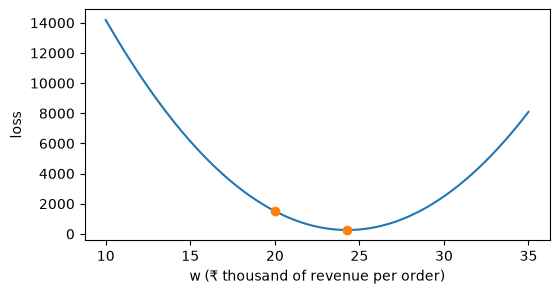

In [9]:
import matplotlib.pyplot as plt

ws = np.linspace(10, 35, 101)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ws, [loss(w) for w in ws])
ax.plot([20, 24.29], [loss(20), loss(24.29)], "o")
ax.set_xlabel("w (₹ thousand of revenue per order)")
ax.set_ylabel("loss")
plt.show()

**How it works:**

- `np.linspace(10, 35, 101)` makes 101 evenly spaced values from 10 to 35 (10, 10.25, 10.5, …, 35): the points to draw.
- `[loss(w) for w in ws]` is a list comprehension (Chapter 17, section 17.6): the loss at each of those 101 values.
- `fig, ax = plt.subplots(figsize=(6, 3))` and `ax.plot(...)` draw a line chart, as in Chapter 18, section 18.11. The second `ax.plot` with `"o"` draws only round markers, no line, at *w* = 20 and 24.29. `plt.show()` displays the chart below the cell.

![A U-shaped curve of the loss against w from 10 to 35, falling from about 14,000 at w = 10 to a minimum of 258 near w = 24.29 and rising to about 8,100 at w = 35; a marker at w = 20 is labeled "you are here: w = 20, loss 1,511.25" and a marker at the bottom is labeled "bottom: w = 24.29, loss 257.68"](figures/fig35-1b-loss-valley.svg)

*Figure 35.2 — The loss for every value of w. You're standing at w = 20; the bottom of the valley is near 24.3.*

### The derivative: the slope of the loss

You're standing at *w* = 20 and want to walk downhill. You need to know which direction is down, and how steep it is. That's what a **derivative** tells you: how much the loss changes for a tiny change in *w*. A negative derivative means increasing *w* lowers the loss; a positive one means increasing *w* raises it; zero means you're at the bottom (or a flat spot).

You can measure it without any calculus. Nudge *w* by a tiny amount and see what happens to the loss:

In [10]:
h = 0.001
print("loss(20)       =", round(loss(20), 4))
print("loss(20.001)   =", round(loss(20 + h), 4))
print("measured slope =", round((loss(20 + h) - loss(20)) / h, 2))

loss(20)       = 1511.25
loss(20.001)   = 1510.6651
measured slope = -584.93


Raising *w* by 0.001 lowered the loss by about 0.585, so the slope is about −585 per unit of *w*. Negative, so *w* should go **up**.

### Where the slope formula comes from

You can build the exact formula from the same nudging idea, in three small steps.

**Warm-up: the slope of a square.** Take f(*w*) = *w*² at *w* = 3 and nudge by 0.001: (3.001² − 3²) ÷ 0.001 = (9.006001 − 9) ÷ 0.001 = 6.001, which is 6 = 2 × 3 plus a tiny bit that shrinks as the nudge shrinks. In general, **the slope of a square is 2 × the thing being squared.**

Now follow one row, Om Sai Provisions (*x* = 4, *y* = 66), at *w* = 20, where its error is 20 × 4 − 66 = 14:

1. **The square reacts to the error.** Nudge the error from 14 to 14.001 and its square changes by 14.001² − 14² = 0.028001, about 2 × 14 × 0.001. So the squared error changes by 2 × error for each unit the error moves.
2. **The error reacts to *w*.** The prediction is *w* × 4, so nudging *w* by a small amount *h* moves the prediction, and the error, by 4 × *h*: *x* times the nudge.
3. **Put them together.** Nudging *w* by *h* moves Om Sai's squared error by about 2 × 14 × 4 × *h*. Per unit of *w*, that's 2 × error × *x*.

The loss is the average of the four rows' squared errors, so its slope is the average of the four rows' slopes:

> derivative of loss with respect to *w* = 2 × average of (error × *x*)
>
> where, for each row, error = *w* × *x* − *y*; *x* is that row's orders; and "average of" means add the four rows and divide by 4.

The error is multiplied by *x* because a weight's effect on a prediction is proportional to the feature it multiplies: nudging *w* moves Fresh Bowl's prediction (12 orders) three times as much as Om Sai's (4 orders). Check it at *w* = 20 using the error column above:

> 2 × (14 × 4 + (−34) × 7 + (−38) × 8 + (−57) × 12) ÷ 4
>
> = 2 × (56 − 238 − 304 − 684) ÷ 4
>
> = 2 × (−1,170) ÷ 4 = **−585** ✓

The formula and the nudge agree. (The nudge gave −584.93 because 0.001 is small but not zero.)

> **Simplification note.** You won't need to work out derivative formulas for real models. Libraries such as scikit-learn and PyTorch calculate them for you (PyTorch does it automatically for any model you write, which Chapter 43 shows). What you need is the meaning: *the derivative is the local slope of the loss, and its sign says which way to move.*

### The bottom of the valley

At the bottom of the valley the slope is zero. For this one-weight model you can solve for that point directly, using the Σ ("add up over the rows") notation from section 22.10:

> 2 × average of ((*w* × *x* − *y*) × *x*) = 0
>
> so Σ(*w* × *x*² − *x* × *y*) = 0 (multiply both sides by 4 and divide by 2)
>
> so *w* × Σ*x*² = Σ*xy*, and *w* = Σ*xy* ÷ Σ*x*²

With the four customers, Σ*xy* = 4 × 66 + 7 × 174 + 8 × 198 + 12 × 297 = 264 + 1,218 + 1,584 + 3,564 = 6,630, and Σ*x*² = 16 + 49 + 64 + 144 = 273. So *w* = 6,630 ÷ 273 = **24.29**, about ₹24,290 of revenue per order: the bottom of Figure 35.2's valley.

---

## 35.5 Gradients: the slope in every direction

A real model has many parameters. Give the line an intercept, **predicted revenue = *w* × orders + *b***, and the loss now depends on two numbers. The loss surface is a bowl instead of a curve, and "downhill" has a direction on a map.

A **partial derivative** is the slope in one parameter's direction, holding the others still. The **gradient** is the vector of all the partial derivatives: one component per parameter. It points in the direction of steepest **increase** in the loss, so you walk the opposite way.

For mean squared error with *w* and *b*:

> slope for *w* = 2 × average of (error × *x*)
>
> slope for *b* = 2 × average of (error)

The intercept adds 1 to every prediction when it rises by 1, so its partial derivative has no *x* in it.

Work out the gradient at the start, *w* = 0 and *b* = 0. Every prediction is 0, so the errors are −66, −174, −198, and −297:

> slope for *w* = 2 × (−66 × 4 − 174 × 7 − 198 × 8 − 297 × 12) ÷ 4
>
> = 2 × (−264 − 1,218 − 1,584 − 3,564) ÷ 4
>
> = 2 × (−6,630) ÷ 4 = **−3,315**
>
> slope for *b* = 2 × (−66 − 174 − 198 − 297) ÷ 4 = 2 × (−735) ÷ 4 = **−367.5**

The gradient is **[−3,315, −367.5]**. Both components are negative, so both *w* and *b* should increase. The *w* component is nine times bigger: the loss is far more sensitive to the slope than to the intercept, because *w* is multiplied by orders of 4 to 12 and *b* by 1. Remember that; it causes trouble in section 35.6.

With a feature matrix that includes a column of ones, as in section 35.3, the whole gradient is one line of NumPy:

In [11]:
X4 = np.column_stack([np.ones(4), x])
weights = np.zeros(2)                      # [b, w], both starting at 0
print(2 * X4.T @ (X4 @ weights - y) / len(y))

[ -367.5 -3315. ]


**How it works:**

- `X4` is the 4 × 2 matrix of [1, orders] rows, and `np.zeros(2)` is the weight vector [*b*, *w*] = [0, 0].
- `X4 @ weights - y` is the vector of four errors.
- `X4.T @ errors` takes the dot product of each **column** of `X4` (first the ones, then the orders) with the errors: the sum of the errors, and the sum of error × *x*. Multiplying by 2 and dividing by `len(y)` (4) turns those sums into the two slopes. That's why the transpose appears in machine learning formulas.
- The answer comes out in the order of X's columns, **ones first**, so the slope for *b* (−367.5) comes before the slope for *w* (−3,315). The hand calculation above listed *w* first. Same two numbers, different order: always check which column is which.

---

## 35.6 Gradient descent, by hand and in NumPy

### The update rule

**Gradient descent** repeats one move: compute the gradient, then step every parameter a small amount in the opposite direction.

> new parameter = old parameter − learning rate × slope for that parameter

The **learning rate** is the size of the step, a setting you choose. A setting chosen by you rather than learned from the data is a **hyperparameter**. Use a learning rate of **0.005**.

### Three steps by hand

**Step 1.** Start at *w* = 0, *b* = 0. The gradient (section 35.5) is [−3,315, −367.5], and the loss is (66² + 174² + 198² + 297²) ÷ 4 = (4,356 + 30,276 + 39,204 + 88,209) ÷ 4 = 162,045 ÷ 4 = **40,511.25**.

> new *w* = 0 − 0.005 × (−3,315) = **16.575**
>
> new *b* = 0 − 0.005 × (−367.5) = **1.8375**

**Step 2.** Predict with *w* = 16.575, *b* = 1.8375. Om Sai: 16.575 × 4 + 1.8375 = 68.14, an error of +2.14. Patel: 16.575 × 7 + 1.8375 = 117.86, error −56.14. Evergreen: 134.44, error −63.56. Fresh Bowl: 200.74, error −96.26. The loss has fallen to **4,115.66**. The slopes are 2 × (2.14 × 4 − 56.14 × 7 − 63.56 × 8 − 96.26 × 12) ÷ 4 = **−1,024.03** for *w* and 2 × (2.14 − 56.14 − 63.56 − 96.26) ÷ 4 = **−106.91** for *b* (to two decimals; the code below carries full precision).

> new *w* = 16.575 + 0.005 × 1,024.03 = **21.695**
>
> new *b* = 1.8375 + 0.005 × 106.91 = **2.372**

**Step 3.** Predictions 89.15, 154.24, 175.93, 262.71; errors 23.15, −19.76, −22.07, −34.29; loss **647.26**; slopes −316.84 and −26.48.

> new *w* = 21.695 + 0.005 × 316.84 = **23.279**
>
> new *b* = 2.372 + 0.005 × 26.48 = **2.504**

| Step | *w* | *b* | Loss | Slope for *w* | Slope for *b* |
|---|---|---|---|---|---|
| 1 | 0.000 | 0.000 | 40,511.25 | −3,315.00 | −367.50 |
| 2 | 16.575 | 1.838 | 4,115.66 | −1,024.03 | −106.91 |
| 3 | 21.695 | 2.372 | 647.26 | −316.84 | −26.48 |
| after 3 | 23.279 | 2.504 | 316.36 | | |

Three things to notice. The loss fell from 40,511 to 316 in three steps. The steps get **smaller on their own**, even though the learning rate is fixed, because the slope flattens as you approach the bottom. And *b* has barely moved.

![Two panels: on the left, four customers as dots with the fitted line after steps 1, 2 and 3 rising toward the best line; on the right, bars of the loss falling from 40,511 to 4,116 to 647 to 316](figures/fig35-2-gradient-steps.svg)

*Figure 35.3 — Three steps of gradient descent by hand. Left: each step's line moves toward the least-squares line. Right: the loss before each step and after the third.*

### The same three steps in NumPy

In [12]:
w, b = 0.0, 0.0
learning_rate = 0.005

for step in range(1, 4):
    error = (w * x + b) - y
    current_loss = np.mean(error ** 2)
    slope_w = 2 * np.mean(error * x)
    slope_b = 2 * np.mean(error)
    print(f"step {step}: w={w:7.3f}  b={b:6.3f}  loss={current_loss:10.2f}  "
          f"slope_w={slope_w:9.2f}  slope_b={slope_b:8.2f}")
    w = w - learning_rate * slope_w
    b = b - learning_rate * slope_b

print(f"after 3: w={w:7.3f}  b={b:6.3f}  loss={np.mean((w * x + b - y) ** 2):10.2f}")

step 1: w=  0.000  b= 0.000  loss=  40511.25  slope_w= -3315.00  slope_b= -367.50
step 2: w= 16.575  b= 1.838  loss=   4115.66  slope_w= -1024.03  slope_b= -106.91
step 3: w= 21.695  b= 2.372  loss=    647.26  slope_w=  -316.84  slope_b=  -26.48
after 3: w= 23.279  b= 2.504  loss=    316.36


**How it works:**

- Each pass through the loop does exactly what you did by hand: predict, find errors, compute the loss and both slopes, then update.
- `np.mean(error * x)` is "average of error × *x*", computed for all four customers at once.
- `for step in range(1, 4)` runs the loop for steps 1, 2, and 3 (Chapter 17, section 17.6).
- Printing *before* updating matches the hand table, where each row shows the parameters that produced that loss. Every number agrees with the table. ✓
- **Format codes.** Inside an f-string, the part after the colon sets the layout: `:7.3f` means 7 characters wide with 3 decimals, `:10.2f` means 10 wide with 2 decimals. Fixed widths line the columns up. The two f-strings in the first `print` sit side by side inside the brackets, and Python joins them into one string; that's just a way to split a long line.

### Running it to the bottom

Let the same loop run for 1,000 steps, and compare with the exact best line. NumPy's `np.polyfit(x, y, 1)` finds the least-squares line directly, without gradient descent:

In [13]:
def descend(x_values, y_values, learning_rate, steps):
    w, b = 0.0, 0.0
    losses = []
    for _ in range(steps):
        error = (w * x_values + b) - y_values
        losses.append(np.mean(error ** 2))
        w -= learning_rate * 2 * np.mean(error * x_values)
        b -= learning_rate * 2 * np.mean(error)
    return w, b, losses

w, b, losses = descend(x, y, 0.005, 1000)
best_w, best_b = np.polyfit(x, y, 1)
best_loss = np.mean((best_w * x + best_b - y) ** 2)
print(f"gradient descent, 1000 steps: w={w:.2f}  b={b:.2f}  loss={losses[-1]:.2f}")
print(f"exact least squares:          w={best_w:.2f}  b={best_b:.2f}  loss={best_loss:.2f}")

gradient descent, 1000 steps: w=27.12  b=-25.00  loss=109.48
exact least squares:          w=28.51  b=-37.21  loss=91.55


**How it works:**

- `descend` wraps the loop in a function, so you can rerun it with other data and settings. It takes the feature (`x_values`), the target (`y_values`), the learning rate, and the number of steps, and returns the final *w*, the final *b*, and the list of losses. Pass everything a function uses as an argument: a function that quietly uses a variable from outside (say, the `y` defined earlier) will give wrong results, with no error, the day you call it with a different feature.
- `for _ in range(steps)` repeats the loop `steps` times. `_` is a name for a value you don't need; here, the step number.
- `w -= ...` is short for `w = w - ...`: the update rule. `losses.append(...)` records the loss before each step, so `losses[-1]` (the last item) is the loss at step 1,000.
- `np.polyfit(x, y, 1)` fits a polynomial of degree 1, which is a straight line, by least squares. It returns the coefficients highest power first: the slope, then the intercept. That's the **reverse** of our `[b, w]` weight vector from section 35.3, so the unpacking order `best_w, best_b` matters.

**Check it by hand.** Section 22.10 gave the least-squares line as a formula, and it agrees. The averages are x̄ = 31 ÷ 4 = 7.75 orders and ȳ = 735 ÷ 4 = 183.75. Then Σ(*x* − x̄)(*y* − ȳ) = 933.75 and Σ(*x* − x̄)² = 32.75, so:

> slope = 933.75 ÷ 32.75 = **28.51**
>
> intercept = ȳ − slope × x̄ = 183.75 − 28.5115 × 7.75 = **−37.21** (using the unrounded slope, 933.75 ÷ 32.75 = 28.5115)

That's exactly where gradient descent is heading.

**Reading it.** After 1,000 steps the loss has fallen from 40,511 to 109.48, close to the best possible 91.55, but the parameters are further off than that suggests: *w* is 27.12 instead of 28.51, and *b* is −25.00 instead of −37.21. The loss surface is a long, narrow valley. It's steep across the *w* direction and almost flat along the *b* direction, so the descent races down the steep wall and then creeps along the flat floor. A small loss doesn't guarantee the parameters have settled.

> **Watch out: a flat loss curve doesn't mean training has finished.** If you judge convergence only by "the loss stopped changing much", you can stop with parameters that are still far from their best values. Here the intercept is off by ₹12,000. Check the parameters too, or better, fix the cause below.

### The fix: scale the feature

The valley is narrow because orders (4 to 12) are much larger than the constant 1 that multiplies *b*. **Center** the feature by subtracting its average, 7.75 orders, and the two directions become equally steep. Now you can use a much bigger learning rate:

In [14]:
x_centered = x - x.mean()
w_c, b_c, losses_c = descend(x_centered, y, 0.05, 150)
print(f"centered, 150 steps: w={w_c:.2f}  b={b_c:.2f}  loss={losses_c[-1]:.2f}")
print(f"back on the original scale: b = {b_c - w_c * x.mean():.2f}")

centered, 150 steps: w=28.51  b=183.75  loss=91.55
back on the original scale: b = -37.21


With the feature centered, 150 steps land exactly on the least-squares answer: a slope of 28.51 and, converted back, an intercept of −37.21. The intercept of the centered model, 183.75, has a plain meaning: it's ȳ, the average revenue of the four customers (₹1,83,750), which is the prediction for a customer with the average number of orders. `b_c - w_c * x.mean()` converts it back, exactly as section 22.10's intercept formula does. Centering is what makes a ten-times-bigger learning rate safe (the uncentered problem diverges above about 0.0145, as you'll see below), and together they need about seven times fewer steps, and land on the right answer. This is why Chapter 36 treats scaling as a routine step before training.

**What to tell the sales head.** "Among these four customers, each extra order goes with about ₹28,500 of extra annual revenue." Don't read the intercept of −37.21 as "a customer with no orders brings in minus ₹37,210": no customer in the data has fewer than 4 orders, and a line is only trustworthy near the data it was fitted on. With four customers this is a teaching example, not a finding.

### The learning rate

*"How do I pick the learning rate?"* Watch the loss. What happens if you change the learning rate? Run the original (uncentered) problem with three of them:

In [15]:
for lr in [0.0005, 0.005, 0.015]:
    _, _, run = descend(x, y, lr, 30)
    print(f"rate {lr:<6}: loss at steps 1-4 = "
          + ", ".join(f"{v:,.0f}" for v in run[:4])
          + f" ... step 30 = {run[-1]:,.0f}")

rate 0.0005: loss at steps 1-4 = 40,511, 35,141, 30,488, 26,456 ... step 30 = 913
rate 0.005 : loss at steps 1-4 = 40,511, 4,116, 647, 316 ... step 30 = 270
rate 0.015 : loss at steps 1-4 = 40,511, 46,679, 53,794, 61,999 ... step 30 = 2,521,040


**How it works:**

- `_, _, run = descend(...)` keeps only the list of losses; the two `_` names throw away *w* and *b*, which this comparison doesn't need.
- `{lr:<6}` prints the rate left-aligned in 6 characters, so the colons line up.
- `f"{v:,.0f}" for v in run[:4]` formats each of the first four losses with a thousands separator and no decimals, and `", ".join(...)` glues the four formatted numbers together with a comma and a space between them. The `+` signs join the three pieces of the line.

**Reading it.**

- **0.0005 is too small.** The loss falls steadily but slowly: still 913 at step 30, more than three times the loss of the better rate.
- **0.005 is about right** for this problem. The loss falls from 40,511 to 316 in three steps and is at 270 by step 30.
- **0.015 is too large.** Each step overshoots the bottom of the valley and lands higher up the other side, so the loss **grows**. By step 30 it has passed 2.5 million, and it keeps climbing. A loss that shoots up to enormous numbers, or to `nan` ("not a number", section 18.1), almost always means the learning rate is too high.

Numbers are hard to compare by eye, so plot the three loss curves on one chart:

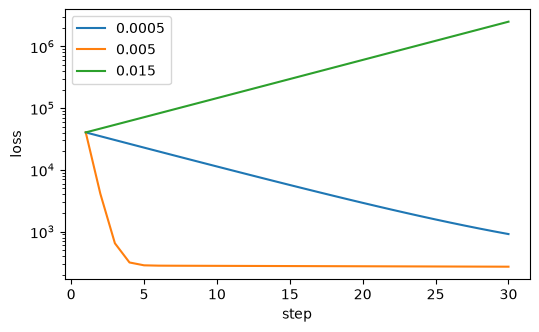

In [16]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for lr in [0.0005, 0.005, 0.015]:
    _, _, run = descend(x, y, lr, 30)
    ax.plot(range(1, 31), run, label=str(lr))
ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.legend()
plt.show()

**How it works:**

- `ax.plot(range(1, 31), run, label=str(lr))` draws one line per learning rate: steps 1 to 30 across, the loss up. `label` names the line, and `ax.legend()` shows the names in a key.
- `ax.set_yscale("log")` makes the vertical axis logarithmic, as in Chapter 15: each gridline is ten times the one below. Without it, the climbing line for 0.015 would squash the other two flat along the bottom.

Figure 35.4 shows the result, with each line labeled directly.

![Loss over 30 steps on a logarithmic scale for three learning rates: 0.0005 falls slowly, 0.005 falls fast and levels off, 0.015 rises steadily](figures/fig35-3-learning-rates.svg)

*Figure 35.4 — The same problem with three learning rates. Too small crawls, about right drops fast, too large climbs away from the answer. The vertical axis is logarithmic: each gridline is ten times the one below.*

> **Try it.** In the learning-rate loop, try 0.014 and 0.0145. One of them converges, slowly, and one diverges, slowly. For this problem the dividing line is about 0.01447, which is 2 divided by the steepness of the valley's steepest direction. You don't need that formula at work; you need the habit of plotting the loss.

### The pattern behind every model

You've now seen the three ingredients of almost every machine learning model:

1. **Parameters**, the numbers the model can adjust (*w* and *b*).
2. **A loss function** that scores how wrong the parameters are (mean squared error).
3. **An optimizer** that changes the parameters to lower the loss (gradient descent).

Linear regression (section 22.10, and for prediction, Chapter 37) uses exactly these, with more features. Logistic regression swaps in a different loss (section 35.9). A neural network (Chapter 43) has thousands or millions of parameters and computes its gradient automatically, but the loop is the one you wrote above. Real libraries add improvements such as **stochastic gradient descent** (computing each step on a random batch of rows instead of all of them, which is much faster on large data) and optimizers such as **Adam** that adjust the step size per parameter. They all follow the downhill slope.

> **Checkpoint (end of sitting B, ten minutes).** Three points, *x* = [1, 2, 3] and *y* = [2, 4, 6]. Start at *w* = 0, *b* = 0 with a learning rate of 0.05. On paper, find the loss, both slopes, and the new *w* and *b* after one step. Then check with `descend(np.array([1, 2, 3.]), np.array([2, 4, 6.]), 0.05, 1)`. *Answer:* errors −2, −4, −6; loss 56 ÷ 3 = 18.67; slope for *w* = 2 × (−28) ÷ 3 = −18.67; slope for *b* = 2 × (−12) ÷ 3 = −8; new *w* = 0.933, new *b* = 0.4.

---

## 35.7 Probability distributions: describing what's likely

A model that predicts a number with a straight line gives one answer. Many models instead give a **probability**: "this lead has a 20% chance of being won". To build and judge those, you need a way to describe how likely every possible outcome is. That description is a **probability distribution**. Chapter 21 (section 21.5) met the normal, binomial, and Poisson distributions with `scipy.stats`, on Riverstone's deliveries. This section revisits them as a model-builder would, adds the simplest one of all, the Bernoulli, and asks when each one fits Riverstone's sales data.

### Bernoulli: one yes-or-no outcome

In 2025 Riverstone received **30** real sales enquiries (after removing duplicate web-form submissions, as in Chapter 13), and **6** were won. One lead is a single trial with two outcomes: won (1) or not won (0). A **Bernoulli distribution** describes it with one parameter, *p*, the probability of a 1.

> P(won) = *p*
>
> P(not won) = 1 − *p*

If *p* = 0.2, a lead is won with probability 0.2 and not won with probability 0.8. Every yes-or-no prediction in this book (will this customer churn, is this transaction fraud, will this lead convert) models the outcome as Bernoulli.

### Binomial: how many yeses out of *n*

*"If each lead has a 20% chance, how likely is it that exactly 6 of 30 are won?"* Counting successes in *n* independent Bernoulli trials gives a **binomial distribution**. Start with a tiny case, as section 21.5 did with deliveries: 3 leads, exactly 1 won, at *p* = 0.2. Write W for won and L for lost. There are three ways, WLL, LWL, and LLW, and each has probability 0.2 × 0.8 × 0.8 = 0.128. You multiply because the leads are independent (Chapter 21's multiplication rule). So P(exactly 1 of 3) = 3 × 0.128 = **0.384**. The general formula does the same counting:

> P(exactly *k* won out of *n*) = C(*n*, *k*) × *p*ᵏ × (1 − *p*)ⁿ⁻ᵏ
>
> where *n* is the number of leads, *k* the number won, and *p* the chance that each one is won.

*p*ᵏ is the chance that *k* particular leads are won, and (1 − *p*)ⁿ⁻ᵏ the chance that the other *n* − *k* are lost. C(*n*, *k*), read "*n* choose *k*", counts how many different sets of *k* leads could be the winners. It has a formula of its own: C(*n*, *k*) = *n*! ÷ (*k*! × (*n* − *k*)!), where *n*! ("*n* factorial") is 1 × 2 × … × *n*. For the tiny case, C(3, 1) = 3! ÷ (1! × 2!) = 6 ÷ 2 = 3: WLL, LWL, LLW. For 6 wins out of 30, let Python count:

In [17]:
from math import comb
from scipy import stats

print(comb(3, 1), comb(30, 6))
print(round(comb(30, 6) * 0.2**6 * 0.8**24, 4))
print(round(stats.binom.pmf(6, 30, 0.2), 4))

3 593775
0.1795
0.1795


**How it works:**

- `comb(n, k)` from Python's built-in `math` module is C(*n*, *k*). There are 593,775 different ways to pick which 6 of 30 leads are the winners.
- The second line is the formula typed out: `0.2**6` is 0.2⁶.
- `stats.binom.pmf(k, n, p)` is the same probability from scipy (section 21.5). The two agree. ✓

> P(6 of 30) = 593,775 × 0.2⁶ × 0.8²⁴ = 593,775 × 0.000064 × 0.0047224 = **0.179**

Even when the true rate is exactly 20%, getting exactly 6 wins out of 30 happens only about 18% of the time. Five wins (0.172) or seven (0.154) are nearly as likely. Chapter 22 used this idea to ask whether a difference in win rates is real or noise.

### Poisson: counts of events in a period

*"How many orders should we expect in a week?"* Riverstone's 173 orders in 2025 fell into 52 weeks, an average of 173 ÷ 52 = **3.327** orders a week. When events arrive independently at a steady average rate, the number in a period follows a **Poisson distribution**, with one parameter, the average rate λ ("lambda"):

> P(*k* events) = λᵏ × e^(−λ) ÷ *k*!

Here *e* is the constant 2.71828 (section 21.5), and *k*! is *k* factorial. For zero orders in a week, λ⁰ = 1 and 0! = 1 (any number to the power 0 is 1, and 0! is 1 by definition), so P(0) = e^(−3.327) = **0.0359**. Over 52 weeks, that predicts 52 × 0.0359 = **1.9** weeks with no orders. Two more rows by hand, each built from the one before:

> P(1) = 3.327 × 0.0359 = 0.119, so 52 × 0.119 = **6.2** weeks
>
> P(2) = 3.327² ÷ 2 × 0.0359 = 0.199, so 52 × 0.199 = **10.3** weeks

(Use the unrounded rate, 173 ÷ 52 = 3.327. Rounded to 3.33, e^(−3.33) is 0.0358, and the fourth decimal changes.)

Does the model describe Riverstone's real weeks? First, count the orders in each week:

In [18]:
orders = pd.read_csv("orders_2025.csv", parse_dates=["order_date"])
week = (orders["order_date"].dt.dayofyear - 1) // 7          # week 0 = 1-7 January
all_weeks = np.bincount(week, minlength=52)
print(len(all_weeks), "weeks counted;", all_weeks[52:].sum(), "orders after week 51")
counts = all_weeks[:52]
rate = counts.mean()
print(f"{counts.sum()} orders in 52 weeks, average {rate:.3f} a week")

52 weeks counted; 0 orders after week 51
173 orders in 52 weeks, average 3.327 a week


**How it works:**

- `parse_dates=["order_date"]` reads the column as dates (section 18.2). `.dt.dayofyear` numbers the days of 2025 from 1 to 365; subtracting 1 and dividing by 7 with `//` (whole-number division) gives a week number from 0.
- `np.bincount(week, minlength=52)` counts how many orders fall into each week number. `minlength=52` asks for at least 52 counts, so a week with no orders still appears, as 0.
- There's a trap in the calendar: 52 × 7 = 364, so 31 December (day 365) would be week 52, a 53rd, one-day "week". The first `print` checks it: `all_weeks` has only 52 entries, and `all_weeks[52:].sum()` (everything from position 52 on) is 0. No order fell on 31 December, so `counts = all_weeks[:52]`, the first 52 weeks, loses nothing, and the 173 orders confirm it.

Then compare the real weeks with what Poisson expects:

In [19]:
print("orders in a week | weeks observed | Poisson expects")
for k in range(9):
    expected = 52 * stats.poisson.pmf(k, rate)
    print(f"{k:>16} | {np.sum(counts == k):>14} | {expected:>15.1f}")

orders in a week | weeks observed | Poisson expects
               0 |              1 |             1.9
               1 |              8 |             6.2
               2 |             10 |            10.3
               3 |             10 |            11.5
               4 |             10 |             9.5
               5 |              7 |             6.3
               6 |              3 |             3.5
               7 |              2 |             1.7
               8 |              1 |             0.7


**How it works:**

- `stats.poisson.pmf(k, rate)` is P(exactly *k*) at the weekly rate (section 21.5), and `52 *` turns it into a number of weeks.
- `counts == k` gives `True` or `False` for each of the 52 weeks; `np.sum` counts the `True`s, because `True` counts as 1 (section 18.1's boolean mask).
- `{k:>16}` prints *k* right-aligned in 16 characters, the width of the heading above it, so the columns line up.

**Reading it.** The Poisson model tracks the real weeks closely: it expects 10.3 weeks with two orders and 11.5 with three, and Riverstone had 10 of each. The first three rows match the hand calculation. That's useful. A demand planner who knows orders are roughly Poisson with a rate of 3.3 a week knows that a week with 8 or more orders happens about once a year by chance alone, and doesn't need an explanation. (Riverstone's rate isn't really constant, since the festive season in October and November is busier; Chapter 40 handles seasonality properly.)

### Normal: the bell curve, and when it lies

The **normal distribution** is the symmetric bell curve described by a mean (μ, "mu") and a standard deviation (σ, "sigma"). Many methods assume it, often silently. Riverstone's order values have a mean of ₹25,060.53 and a standard deviation of ₹17,398.71. If order values were normal with those numbers, what would follow?

In [20]:
values = orders["order_value"]
bell = stats.norm(values.mean(), values.std())
print(f"mean ₹{values.mean():,.2f}  sd ₹{values.std():,.2f}  median ₹{values.median():,.0f}")
above, below = 1 - bell.cdf(50000), bell.cdf(0)
print(f"above ₹50,000: normal predicts {above:.1%}, actual {np.mean(values > 50000):.1%}")
print(f"below ₹0:      normal predicts {below:.1%}, actual {np.mean(values < 0):.1%}")

mean ₹25,060.53  sd ₹17,398.71  median ₹21,375
above ₹50,000: normal predicts 7.6%, actual 9.2%
below ₹0:      normal predicts 7.5%, actual 0.0%


**How it works:**

- `stats.norm(mean, sd)` builds a normal distribution with Riverstone's mean and standard deviation (pandas' `.std()`, which divides by *n* − 1 as in Chapter 21).
- `cdf(x)`, the **cumulative distribution function** from section 21.5, is the share of the distribution at or below *x*. So `bell.cdf(0)` is the share below ₹0, and `1 - bell.cdf(50000)` is the share **above** ₹50,000: everything that isn't at or below it.
- `values > 50000` is `True` or `False` for each order, and its mean is the share of `True`s, because `True` counts as 1: the actual share of large orders.
- `{above:.1%}` prints a fraction as a percentage with one decimal: 0.0763 becomes 7.6%.

**Reading it.** The normal model says 7.5% of orders should have a **negative** value, which is impossible. It also underestimates large orders (7.6% predicted, 9.2% actual). Order values are **skewed**: most are moderate, a few are large, and none can be below zero, which is why the median (₹21,375) sits well below the mean. A normal distribution is a poor description of money amounts, counts of rare events, waiting times, and anything bounded at zero. Chapter 21 (section 21.4) showed how to check the shape of data with a histogram before assuming.

| Distribution | Describes | Parameters | Riverstone example | Used in |
|---|---|---|---|---|
| Bernoulli | one yes-or-no outcome | *p* | is this lead won? | logistic regression, classifiers (Ch 37) |
| Binomial | number of yeses in *n* tries | *n*, *p* | leads won out of 30 | late deliveries (Ch 21), win-rate checks (Ch 22), A/B tests (Ch 30) |
| Poisson | count of events in a period | λ | orders per week | complaints per week (Ch 21), demand and anomaly models (Ch 40) |
| Normal | a measurement that clusters symmetrically | mean, standard deviation | *not* order values | crate weights (Ch 21), sampling (Ch 22), linear regression errors (Ch 37) |

---

## 35.8 Likelihood and maximum likelihood

### Turning the question around

So far you've asked: *given* a parameter, how likely is the data? Machine learning asks the reverse: *given* the data, which parameter is most believable?

The **likelihood** of a parameter value is the probability of the data you actually observed, calculated as if that value were true. Start with three leads whose outcomes were won, lost, lost. If the win rate is 0.2, the chance of exactly that sequence is 0.2 × 0.8 × 0.8 = 0.128; if it's 0.5, it's 0.5 × 0.5 × 0.5 = 0.125. You multiply because the leads are independent (Chapter 21). So 0.2 explains these three outcomes slightly better than 0.5 does.

For Riverstone's 30 leads with 6 won, the same multiplication gives six factors of *p* (one per win) and 24 factors of (1 − *p*) (one per loss):

> likelihood(*p*) = *p*⁶ × (1 − *p*)²⁴

(The C(30, 6) from the binomial formula is the same for every *p*, so it doesn't change which *p* is best, and it's usually left out.)

Try three values:

| *p* | *p*⁶ × (1 − *p*)²⁴ |
|---|---|
| 0.1 | 0.000001 × 0.079766 = 0.0000000798 |
| 0.2 | 0.000064 × 0.0047224 = 0.000000302 |
| 0.3 | 0.000729 × 0.00019158 = 0.000000140 |

Numbers this small are usually written in **scientific notation** (section 18.1): 0.000000302 is 3.02 × 10⁻⁷, "move the decimal point 7 places left", and Python prints it as `3.02e-07`.

A win rate of 0.2 makes the observed data about 3.8 times as likely as 0.1 and about 2.2 times as likely as 0.3. The **maximum likelihood estimate (MLE)** is the parameter value that makes the observed data most likely.

### Why everyone uses the log

Those likelihoods are tiny, and with 30,000 leads instead of 30 they'd be too small for a computer to store (they'd round to zero). So in practice you work with the **log-likelihood**: the natural logarithm of the likelihood. Section 31.0 showed the one rule that makes this work: logs turn multiplication into addition, ln(a × b) = ln(a) + ln(b). They also keep numbers manageable, and because the log always rises when its input rises, the best *p* is the same.

### Logarithms: four more facts

Section 31.0 used logs of numbers bigger than 1, such as order counts. Probabilities are between 0 and 1, and this section and the next need four more facts.

1. **Numbers below 1 have negative logs.** ln 1 = 0, and ln *e* = 1 (the natural log is the log "based on" *e* ≈ 2.718). Below 1 the log is negative: ln 0.2 = −1.6094 and ln 0.8 = −0.2231. So the log of every probability is negative, and a log-likelihood is always a negative number.
2. **The power rule.** A power is repeated multiplication, and each multiplication becomes an addition, so ln(*p*⁶) = 6 × ln *p*. That's how the likelihood *p*⁶ × (1 − *p*)²⁴ becomes 6 × ln *p* + 24 × ln(1 − *p*).
3. **ln 0 is minus infinity.** The closer a probability gets to 0, the more negative its log, with no limit. A predicted probability of exactly 0 (or 1, for the other outcome) breaks every formula in section 35.9.
4. **Other bases.** The log **base 2**, written log₂, asks "2 to what power gives this number?" log₂ 8 = 3 because 2³ = 8, and log₂ 0.5 = −1 because 2⁻¹ = ½. You convert from the natural log by dividing by ln 2 = 0.6931: log₂ *x* = ln *x* ÷ ln 2. Section 35.9 uses base 2.

Check all four in NumPy. Before you run it, predict the last line of output:

In [21]:
print(np.log([1, np.e, 0.2, 0.8]).round(4))
print(round(np.log(0.2 * 0.8), 4), round(np.log(0.2) + np.log(0.8), 4))
print(round(np.log(0.2 ** 6), 4), round(6 * np.log(0.2), 4))
print(np.log2([1, 2, 4, 8, 16, 0.5, 0.25]))
print(round(np.log(0.2) / np.log(2), 4), round(np.log2(0.2), 4))

[ 0.      1.     -1.6094 -0.2231]
-1.8326 -1.8326
-9.6566 -9.6566
[ 0.  1.  2.  3.  4. -1. -2.]
-2.3219 -2.3219


**How it works:**

- `np.log` is the natural log, as in section 31.0; given a list, it takes the log of each value. `np.e` is the constant *e*.
- The second line checks the product rule on two probabilities: ln(0.2 × 0.8) = ln 0.16 equals ln 0.2 + ln 0.8. The third checks the power rule.
- `np.log2` is the log base 2: 1, 2, 4, 8, 16 give 0 to 4, and a half and a quarter give −1 and −2. The last line converts ln 0.2 to base 2 by dividing by ln 2, and matches `np.log2(0.2)`.
- `np.log(0)` returns `-inf` (minus infinity), with a warning, `divide by zero encountered in log`. Python's `math.log(0)` stops with `ValueError: math domain error`. You'll also meet `np.log1p(x)`, which is ln(1 + *x*), in Chapter 36. In a spreadsheet, `LN(x)` is the natural log and `LOG(x, 2)` is base 2.

Now the log-likelihood of the 30 leads:

> log-likelihood(*p*) = 6 × ln(*p*) + 24 × ln(1 − *p*)
>
> at *p* = 0.2: 6 × ln(0.2) + 24 × ln(0.8) = 6 × (−1.60944) + 24 × (−0.22314) = −9.65663 − 5.35545 = **−15.0121**

Search every value of *p* from 0.001 to 0.999 and let NumPy find the best:

In [22]:
leads = pd.read_csv("leads_2025.csv")
won = leads["won"].to_numpy()
print(len(won), "leads,", won.sum(), "won")

p_grid = np.linspace(0.001, 0.999, 999)
log_likelihood = won.sum() * np.log(p_grid) + (len(won) - won.sum()) * np.log(1 - p_grid)
best = p_grid[np.argmax(log_likelihood)]
print(f"maximum likelihood estimate of p: {best:.3f}")
print(f"log-likelihood there: {log_likelihood.max():.4f}")
print(f"sample win rate: {won.mean():.3f}")

30 leads, 6 won
maximum likelihood estimate of p: 0.200
log-likelihood there: -15.0121
sample win rate: 0.200


**How it works:**

- `leads["won"].to_numpy()` is the 30 outcomes as 1s and 0s, so `won.sum()` counts the wins and `won.mean()` is the win rate.
- `np.linspace(0.001, 0.999, 999)` makes 999 evenly spaced candidate values of *p* (0.001, 0.002, …, 0.999), as it made the *w* values in section 35.4.
- The log-likelihood line is the formula above, computed for all 999 values at once: wins × ln *p* + losses × ln(1 − *p*).
- `np.argmax` returns the position of the largest value, and `p_grid[...]` looks up the *p* at that position.

The maximum likelihood estimate is **0.200**, exactly the sample win rate, 6 ÷ 30. That's not a coincidence: for a Bernoulli outcome, the MLE is always the observed proportion, and for a Poisson count it's the observed average (3.327 orders a week). The MLE confirms the obvious in simple cases. Its value is that the same principle works for models where there's no obvious answer, like a lead-scoring model with twenty features.

![A curve of the likelihood of the lead win rate p, rising from zero to a single peak at p = 0.2 and falling back toward zero by p = 0.5, with points marked at 0.1, 0.2 and 0.3](figures/fig35-4-likelihood.svg)

*Figure 35.5 — The likelihood of each possible win rate, given 6 wins in 30 leads. The peak, the maximum likelihood estimate, is at 0.2. The curve is wide: rates from about 0.1 to 0.35 remain fairly plausible with only 30 leads.*

### Why this matters for models

**Training a model is maximum likelihood estimation.** A model's parameters decide the probabilities it assigns; fitting it means finding the parameters under which the training data is most likely. Two facts connect this to what you already know:

- For a model that predicts probabilities of yes-or-no outcomes, maximizing the log-likelihood is the same as minimizing **log loss** (section 35.9).
- For a model that predicts numbers, if you assume the errors are normally distributed, maximizing the likelihood is the same as minimizing **mean squared error**. That's where section 35.4's loss comes from.

---

## 35.9 Entropy, cross-entropy, and log loss

### Entropy: how uncertain is an outcome?

*"Before we look at anything about a lead, how uncertain are we about whether it will be won?"* Information theory answers with one idea, **surprise**, measured in **bits**.

The **surprise** of an outcome that had probability *q* is −log₂ *q* bits. A coin landing heads (½) is 1 bit of surprise; a 1-in-4 event is 2 bits; a 1-in-8 event is 3 bits. The rarer the outcome, the bigger the surprise, and a certain outcome (*q* = 1) is no surprise at all: −log₂ 1 = 0. The minus sign is there because the log of a probability is negative (section 35.8), and a surprise should be a positive number.

For a Riverstone lead at *p* = 0.2, a win is −log₂ 0.2 = **2.32 bits** of surprise, and a loss is −log₂ 0.8 = **0.32 bits**. **Entropy** is the average surprise, weighting each outcome by how often it happens: 0.2 × 2.32 + 0.8 × 0.32 = **0.722 bits**. As a formula, for a yes-or-no outcome with probability *p*:

> entropy = −(*p* × log₂ *p* + (1 − *p*) × log₂ (1 − *p*))
>
> at *p* = 0.2: −(0.2 × (−2.3219) + 0.8 × (−0.3219))
>
> = −(−0.4644 − 0.2575) = **0.722 bits**

A fair coin (*p* = 0.5) has entropy −(0.5 × (−1) + 0.5 × (−1)) = **1 bit**, the most uncertain a yes-or-no outcome can be.

Less than 1 bit, because leads are usually not won, so you're less uncertain than with a coin. An outcome that's certain (*p* = 0 or 1) has entropy 0.

### Information gain: the preview of decision trees

Entropy lets you measure how much a piece of information reduces uncertainty. Split Riverstone's leads by source:

| Group | Leads | Won | Win rate | Entropy |
|---|---|---|---|---|
| All leads | 30 | 6 | 20.0% | 0.722 |
| Website | 14 | 1 | 7.1% | 0.371 |
| Every other source | 16 | 5 | 31.3% | 0.896 |

Check the website entropy:

> −(1/14 × log₂(1/14) + 13/14 × log₂(13/14))
>
> = −(0.0714 × (−3.8074) + 0.9286 × (−0.1069))
>
> = 0.2720 + 0.0993 = 0.371 ✓

After the split, the average uncertainty, weighted by group size, is 14/30 × 0.371 + 16/30 × 0.896 = 0.173 + 0.478 = **0.651 bits**. Knowing whether a lead came through the website reduced uncertainty from 0.722 to 0.651 bits, an **information gain** of **0.071 bits**. A decision tree (Chapter 37) builds itself by trying every possible split and choosing the one with the biggest gain, then repeating inside each branch.

### Cross-entropy and log loss: scoring probability predictions

Entropy measures uncertainty when you know the true probabilities. **Cross-entropy** is the average surprise when you use **predicted** probabilities and then see the real outcomes: each outcome costs the surprise of the probability you gave it. For machine learning it's written with natural logs instead of log₂, averaged over rows, and called **log loss** (or **binary cross-entropy**). Measured with natural logs, the unit is the **nat** instead of the bit; dividing by ln 2 converts nats to bits (section 35.8).

> log loss = −average of (*y* × ln(predicted *p*) + (1 − *y*) × ln(1 − predicted *p*))

For each row, only one term is active, because *y* is 1 or 0. If the lead was won (*y* = 1), the cost is −ln(predicted *p*). If not (*y* = 0), it's −ln(1 − predicted *p*).

Suppose a scoring tool gave five past leads these probabilities of being won, and here's what happened:

| Lead | Predicted *p* | Won? | Cost |
|---|---|---|---|
| A | 0.9 | yes | −ln 0.9 = 0.105 |
| B | 0.7 | yes | −ln 0.7 = 0.357 |
| C | 0.2 | no | −ln 0.8 = 0.223 |
| D | 0.1 | no | −ln 0.9 = 0.105 |
| E | 0.8 | no | −ln 0.2 = 1.609 |

> log loss = (0.105 + 0.357 + 0.223 + 0.105 + 1.609) ÷ 5 = 2.399 ÷ 5 = **0.480**

Look at lead E. The tool was 80% sure it would be won, and it wasn't. That one confident mistake costs more than the other four rows together. Log loss is harsh on confident wrong answers by design: a prediction of 0.99 for a lead that isn't won costs −ln 0.01 = 4.6, and a prediction of exactly 1.0 costs −ln 0, which is infinity (section 35.8). A model trained on log loss learns to say "80%" only when it has earned it.

### Installing scikit-learn

To check the hand calculation against a library, you need **scikit-learn**, Python's standard machine learning library. This chapter uses two of its functions as cross-checks; Chapter 36 teaches it properly, and every chapter from here to Chapter 44 uses it. It isn't among the packages installed so far. In a terminal, activate the book's virtual environment (Chapter 17, section 17.0), then install it and record it in `requirements.txt`, as in section 17.12:

**`bash`, not run by this notebook.** Run it in the tool the chapter names.

```bash
python -m pip install scikit-learn
python -m pip freeze > requirements.txt
```

- `python -m pip install scikit-learn` downloads scikit-learn and the packages it needs into the active environment.
- `python -m pip freeze > requirements.txt` rewrites the list of installed packages, so the new one is recorded.

(If you keep your work in a uv project, as in Chapter 30, `uv add scikit-learn` does both.) Then check it in your notebook:

In [23]:
import sklearn
print(sklearn.__version__)

1.9.0


- The package is called `scikit-learn` when you install it and `sklearn` when you import it.
- `__version__` confirms which version you have. This chapter's outputs were checked with 1.9.1; any recent version gives the same numbers for the two functions used here.

### Log loss in code

In [24]:
from sklearn.metrics import log_loss

y_true = np.array([1, 1, 0, 0, 0])
y_pred = np.array([0.9, 0.7, 0.2, 0.1, 0.8])
by_hand = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
print(f"log loss by hand:     {by_hand:.3f}")
print(f"log loss, sklearn:    {log_loss(y_true, y_pred):.3f}")

log loss by hand:     0.480


log loss, sklearn:    0.480


**How it works:**

- `from sklearn.metrics import log_loss` loads one function from scikit-learn's `metrics` module, where its scoring functions live.
- `by_hand` is the formula above, for all five leads at once. `np.log` is the natural log, so the answer is in nats.
- `log_loss(y_true, y_pred)` takes the real outcomes first and the predicted probabilities second, and agrees with the hand calculation. ✓

Now the benchmark: a "model" that knows nothing except the overall win rate, and predicts 0.2 for every one of the 30 leads.

In [25]:
base_rate = np.full(len(won), won.mean())                  # predict 0.2 for every lead
print(f"always predicting 0.2 on the 30 leads: {log_loss(won, base_rate):.4f} nats"
      f" = {log_loss(won, base_rate) / np.log(2):.4f} bits")
print(f"-(log-likelihood at p=0.2) / 30:       {-log_likelihood.max() / 30:.4f}")

always predicting 0.2 on the 30 leads: 0.5004 nats = 0.7219 bits
-(log-likelihood at p=0.2) / 30:       0.5004


**How it works:** `np.full(len(won), won.mean())` builds an array of 30 copies of the win rate, 0.2: the base-rate model. Dividing by `np.log(2)`, which is ln 2, converts nats to bits. The last line reuses `log_likelihood` from section 35.8.

**Reconcile three ideas.** The three last numbers are the same quantity seen three ways:

- A model that always predicts the base rate of 0.2 has a log loss of **0.5004 nats**.
- In bits, that's **0.7219**, exactly the entropy of the outcome from earlier in this section. ✓ When your predictions match the true rate, cross-entropy equals entropy; any worse predictions give a higher cross-entropy.
- It's also the negative log-likelihood at *p* = 0.2 (section 35.8), −(−15.0121) ÷ 30 = **0.5004**. ✓ **Minimizing log loss is maximizing likelihood.**

That gives you a benchmark for these 30 leads: a model that doesn't beat a log loss of about 0.50 on them knows nothing beyond the overall win rate. Chapter 36 opens Riverstone's full CRM, where the win rate is about 7.7% and the base-rate benchmark on its 2025 leads is about 0.26; the method is the same. Chapter 39 uses the same idea to evaluate a real lead-scoring model.

> **Watch out: accuracy hides what log loss shows.** **Accuracy** is the share of predictions that turn out right: correct ÷ all. A "model" that says *not won* for every lead is 24 ÷ 30 = **80% accurate** on Riverstone's 30 leads, while being useless. Accuracy only counts right and wrong answers; log loss scores how well the probabilities match reality, and punishes false confidence. When someone quotes an accuracy figure, ask for the base rate first.

> **Checkpoint (end of sitting C, ten minutes).** Four leads, of which only the first was won, scored [0.5, 0.5, 0.25, 0.25]. By hand, find the entropy of a 1-in-4 win rate in bits, and the log loss of these four predictions in nats. Check the log loss with `log_loss([1, 0, 0, 0], [0.5, 0.5, 0.25, 0.25])`. *Answer:* entropy = 0.25 × 2 + 0.75 × 0.415 = 0.811 bits; log loss = (0.693 + 0.693 + 0.288 + 0.288) ÷ 4 = 0.490 nats.

---

## 35.10 Principal component analysis (PCA)

### The idea: one direction that says most

*"We track seven numbers for every customer. Can we summarize them with fewer?"* When several columns move together, they carry overlapping information. **Principal component analysis (PCA)** finds new axes, called **principal components**, that point along the directions where the data spreads out most. The first component captures as much of the spread as any single direction can; the second captures the most of what's left, at right angles to the first; and so on. Keep the first few and you've compressed the data with little loss.

"Spread" here is **variance**, the average squared distance from the mean (Chapter 21). PCA ranks directions by how much variance the data has along them.

### A small example by hand

Five customers, two features: orders and revenue in ₹ ten-thousands (so Sharma Hardware's ₹5,02,775 becomes 50). Revenue is measured in ten-thousands so that the two columns have spreads of a similar size; the full example below shows what happens when they don't.

| Customer | Orders | Revenue (₹10k) |
|---|---|---|
| Sharma Hardware | 16 | 50 |
| Metro Mart | 16 | 33 |
| Harbour Traders | 10 | 41 |
| Patel Kitchenware | 7 | 17 |
| Blue Bay Cafe | 4 | 5 |

**Step 1: center.** The averages are 53 ÷ 5 = 10.6 orders and 146 ÷ 5 = 29.2. Subtract them:

| Customer | Orders − 10.6 | Revenue − 29.2 |
|---|---|---|
| Sharma | 5.4 | 20.8 |
| Metro | 5.4 | 3.8 |
| Harbour | −0.6 | 11.8 |
| Patel | −3.6 | −12.2 |
| Blue Bay | −6.6 | −24.2 |

**Step 2: the covariance matrix.** The **covariance** of two columns is the average product of their centered values (dividing by *n* − 1 = 4, as for a sample standard deviation). It's positive when they rise together. The **covariance matrix** holds every column's variance on the diagonal and each pair's covariance off it.

> variance of orders = (5.4² + 5.4² + 0.6² + 3.6² + 6.6²) ÷ 4
>
> = (29.16 + 29.16 + 0.36 + 12.96 + 43.56) ÷ 4 = 115.2 ÷ 4 = **28.8**
>
> variance of revenue = (20.8² + 3.8² + 11.8² + 12.2² + 24.2²) ÷ 4
>
> = (432.64 + 14.44 + 139.24 + 148.84 + 585.64) ÷ 4 = 1,320.8 ÷ 4 = **330.2**
>
> covariance = (5.4 × 20.8 + 5.4 × 3.8 + (−0.6) × 11.8 + (−3.6) × (−12.2) + (−6.6) × (−24.2)) ÷ 4
>
> = (112.32 + 20.52 − 7.08 + 43.92 + 159.72) ÷ 4 = 329.4 ÷ 4 = **82.35**

So the covariance matrix is:

| | Orders | Revenue |
|---|---|---|
| **Orders** | 28.8 | 82.35 |
| **Revenue** | 82.35 | 330.2 |

The same three numbers in NumPy:

In [26]:
small = np.array([[16, 50], [16, 33], [10, 41], [7, 17], [4, 5]], dtype=float)
centered = small - small.mean(axis=0)
cov = centered.T @ centered / (len(small) - 1)
print("covariance matrix:\n", cov)

covariance matrix:
 [[ 28.8   82.35]
 [ 82.35 330.2 ]]


**How it works:**

- `small` is the five customers as a 5 × 2 matrix. `small.mean(axis=0)` averages **down** each column (`axis=0`, the opposite of section 35.2's `axis=1`), giving [10.6, 29.2], and subtracting it takes those averages from every row: step 1.
- `centered.T @ centered` is matrix times matrix (section 35.3): (2 × 5) @ (5 × 2) gives 2 × 2. Each entry is the dot product of one centered column with another, which is exactly the sum of products you did by hand. Dividing by `len(small) - 1`, 4, makes it the covariance matrix. Compare it with the three hand calculations. ✓

**Step 3: find the direction of most variance.** A direction is an arrow of length 1. Give each customer a **score** along it: the dot product of its centered row with the direction. The variance of the five scores is the spread of the data along that direction. So try some directions, measured as angles from the orders axis: 0° points along orders, 90° along revenue.

In [27]:
for deg in [0, 30, 60, 75.7, 90, 120]:
    u = np.array([np.cos(np.radians(deg)), np.sin(np.radians(deg))])
    print(f"{deg:>5}°  direction {u.round(3)}  variance {np.var(centered @ u, ddof=1):7.2f}")

    0°  direction [1. 0.]  variance   28.80
   30°  direction [0.866 0.5  ]  variance  175.47
   60°  direction [0.5   0.866]  variance  326.17
 75.7°  direction [0.247 0.969]  variance  351.23
   90°  direction [0. 1.]  variance  330.20
  120°  direction [-0.5    0.866]  variance  183.53


**How it works:**

- `np.radians`, `np.cos`, and `np.sin` turn an angle into the arrow of length 1 that points that way. You don't need the trigonometry: 0° gives [1, 0], pure orders, and 90° gives [0, 1], pure revenue.
- `centered @ u` is the five customers' scores along `u`, a matrix times a vector.
- `np.var(..., ddof=1)` is their variance, dividing by *n* − 1 like the hand calculation (`ddof=1` means "take 1 off *n*"; NumPy's default divides by *n*).

**Reading it.** Along 0° the variance is 28.8, the variance of orders; along 90° it's 330.2, the variance of revenue. ✓ The spread peaks near **75.7°**, at **351.23**, more than either column alone, in the direction **[0.247, 0.969]**: mostly revenue, with some orders. That's the first principal component. It's a "customer size" axis.

Trying angles works for two columns, but not for seven. Linear algebra has a shortcut, because the best direction has a special property: multiplying it by the covariance matrix only **stretches** it, without turning it. Check it:

In [28]:
best = np.array([0.247, 0.969])
print("cov @ best:    ", (cov @ best).round(2))
print("351.23 * best: ", (351.23 * best).round(2))
print("cov @ [1, 0]:  ", cov @ np.array([1.0, 0.0]))

cov @ best:     [ 86.91 340.3 ]
351.23 * best:  [ 86.75 340.34]
cov @ [1, 0]:   [28.8  82.35]


`cov @ best` is 351.23 times `best`, to within the rounding of 0.247 and 0.969: the same direction, stretched. `cov @ [1, 0]` gives [28.8, 82.35], which points somewhere quite different from [1, 0]: that direction was turned. A direction the matrix only stretches is an **eigenvector** of the matrix, and the stretch factor is its **eigenvalue**. For a covariance matrix, the eigenvectors are the **principal components**, and each eigenvalue is the variance along its component: 351.23 for the first.

Written out, "stretch without turning" is cov × direction = eigenvalue × direction. With the direction written [*u*, *v*] (its orders and revenue parts), the first row says 28.8 × *u* + 82.35 × *v* = 351.23 × *u*, which is (28.8 − 351.23) × *u* + 82.35 × *v* = 0. That gives *v* = 3.915 × *u*, and scaled to length 1, **[0.247, 0.969]**, the direction the table found.

For reference, and for a 2 × 2 covariance matrix only (with variances *a* and *d* and covariance *c*), the larger eigenvalue has a formula. NumPy does the same job for a matrix of any size.

> largest eigenvalue = (*a* + *d*) ÷ 2 + √(((*a* − *d*) ÷ 2)² + *c*²)
>
> = (28.8 + 330.2) ÷ 2 + √(((28.8 − 330.2) ÷ 2)² + 82.35²)
>
> = 179.5 + √(22,710.49 + 6,781.52) = 179.5 + √29,492.01
>
> = 179.5 + 171.73 = **351.23**

The total variance is 28.8 + 330.2 = 359.0, so the first component holds 351.23 ÷ 359.0 = **97.8%** of it. The second holds 359.0 − 351.23 = 7.77, or 2.2%.

NumPy finds every eigenvalue and eigenvector at once:

In [29]:
eigenvalues, eigenvectors = np.linalg.eigh(cov)
print(eigenvalues.round(2))
print(eigenvectors.round(3))

[  7.77 351.23]
[[-0.969  0.247]
 [ 0.247  0.969]]


**How it works:**

- `np.linalg.eigh` finds the eigenvalues and eigenvectors of a symmetric matrix (a covariance matrix is always symmetric: the top right equals the bottom left). It returns two things, unpacked into two names.
- The eigenvalues come **smallest first**: 7.77, then 351.23.
- Each **column** of `eigenvectors` is one direction, in the same order: the second column, [0.247, 0.969], goes with 351.23.

**Step 4: project.** Each customer's **score** on the first component is the dot product of its centered row with the direction. Sharma: 5.4 × 0.247 + 20.8 × 0.969 = 1.34 + 20.15 = **21.49**. Blue Bay: −6.6 × 0.247 + (−24.2) × 0.969 = −1.63 − 23.45 = **−25.08**. One number per customer now says most of what the two columns said. In code, after putting the largest eigenvalue first:

In [30]:
order = np.argsort(eigenvalues)[::-1]
print("order:", order)
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
pc1 = eigenvectors[:, 0] * np.sign(eigenvectors[1, 0])    # point it toward higher revenue
print("share of variance:", (eigenvalues / eigenvalues.sum()).round(3))
print("first component direction:", pc1.round(3))
print("scores on PC1:", (centered @ pc1).round(2))

order: [1 0]
share of variance: [0.978 0.022]
first component direction: [0.247 0.969]
scores on PC1: [ 21.49   5.02  11.28 -12.71 -25.08]


**How it works:**

- `np.argsort(eigenvalues)` gives the **positions** of the values from smallest to largest, here [0, 1]. `[::-1]` reverses any array or list, so `order` is [1, 0]: largest first.
- `eigenvalues[order]` puts the values in that order. `eigenvectors[:, order]` means "all rows, columns in this order", so the columns (the directions) move with their eigenvalues.
- `eigenvectors[:, 0]` is the first column, PC1. `eigenvectors[1, 0]` is row 1, column 0: its revenue part. An eigenvector's sign is arbitrary: [0.247, 0.969] and [−0.247, −0.969] describe the same axis. `np.sign` gives +1 or −1, so multiplying by the sign of the revenue part makes "higher score = bigger customer", and the output is stable and readable.
- `centered @ pc1` is the five scores, matching the hand values for Sharma (21.49) and Blue Bay (−25.08). ✓

![Five customers plotted by orders and revenue, orders drawn three times wider than revenue, with a long arrow through their center along the first principal component and a short arrow at right angles for the second](figures/fig35-5-pca-small.svg)

*Figure 35.6 — The five customers and their principal components. The first component runs along the "customer size" direction and holds 97.8% of the variance; the short second component holds the rest.*

### All 23 customers, seven features

Now the real version: seven features per customer, which you can't draw. First, the mistake.

In [31]:
features = ["orders", "revenue", "avg_order_value", "avg_discount_pct",
            "storage_share", "kitchen_share", "industrial_share"]
F = customers[features].to_numpy(dtype=float)

def pca(matrix):
    centered = matrix - matrix.mean(axis=0)
    values, vectors = np.linalg.eigh(np.cov(centered, rowvar=False))
    order = np.argsort(values)[::-1]
    return values[order] / values.sum(), vectors[:, order], centered @ vectors[:, order]

share_raw, vectors_raw, _ = pca(F)
print("UNSCALED share of variance, first 3 components:", share_raw[:3].round(4))
print("UNSCALED PC1 weights (size only):")
print(pd.Series(np.abs(vectors_raw[:, 0]), index=features).round(3).to_string())

UNSCALED share of variance, first 3 components: [0.9978 0.0022 0.    ]
UNSCALED PC1 weights (size only):
orders              0.000
revenue             1.000
avg_order_value     0.027
avg_discount_pct    0.000
storage_share       0.000
kitchen_share       0.000
industrial_share    0.000


**How it works:**

- `features` lists seven columns, and `.to_numpy(dtype=float)` turns them into a 23 × 7 matrix of decimals, `F`.
- `pca` packs section 35.10's steps into a function: center, covariance matrix, eigenvectors, largest first. `np.cov(centered, rowvar=False)` is the covariance matrix; `rowvar=False` says the **columns** are the variables (NumPy's default is rows). It divides by *n* − 1, like the hand calculation.
- The function returns three things: each component's share of the variance, the directions (one per column), and every customer's scores. `share_raw, vectors_raw, _ = pca(F)` unpacks them and throws away the scores with `_`.
- `vectors_raw[:, 0]` is PC1's weights, one per feature. `np.abs` drops their signs, since only their size matters here, and `pd.Series(..., index=features)` labels each weight with its feature's name.

**Reading the wrong version.** The first component "explains" 99.8% of the variance, which sounds wonderful and means nothing. Its weights are almost entirely on revenue. Revenue is measured in rupees and varies by hundreds of thousands, while shares vary between 0 and 1, so revenue's variance swamps everything. This unscaled PCA has rediscovered "revenue" and thrown away the other six features.

The fix is to **standardize** each column first: subtract the mean and divide by the standard deviation, so every feature has a standard deviation of 1 and an equal chance to matter. Each value becomes a z-score (Chapter 21, section 21.4): how many standard deviations it sits from its column's mean.

In [32]:
F_std = (F - F.mean(axis=0)) / F.std(axis=0)
print("means:", F_std.mean(axis=0).round(2))
print("standard deviations:", F_std.std(axis=0))

means: [ 0.  0.  0. -0. -0. -0. -0.]
standard deviations: [1. 1. 1. 1. 1. 1. 1.]


**How it works:**

- `F.mean(axis=0)` and `F.std(axis=0)` are each column's mean and standard deviation; subtracting and dividing works column by column, as in the small example.
- Every column now has a mean of 0 and a standard deviation of 1. `-0.` is zero too: a tiny negative number, such as −0.000000000000001, rounded to two decimals keeps its minus sign.
- NumPy's `.std()` divides by *n*, while pandas' `.std()` (Chapter 21, and section 35.7) and `np.cov` divide by *n* − 1. Either works for PCA, and scikit-learn's `StandardScaler` (Chapter 36) divides by *n*. The only visible effect: the standardized covariance matrix has 23 ÷ 22 = 1.045 on its diagonal instead of exactly 1, and the shares of variance don't change.

Now run the same `pca` function on the standardized columns:

In [33]:
share, vectors, scores = pca(F_std)
print("share of variance:", share.round(3))
print(f"first two components together: {share[:2].sum():.1%}")

share of variance: [0.535 0.205 0.154 0.084 0.02  0.002 0.   ]
first two components together: 73.9%


Before reading the weights, fix their signs by a rule, as in the small example, so every run reads the same way. Here the rule is: flip PC1 so that industrial share has a positive weight, and PC2 so that storage share does.

In [34]:
signs = np.sign(vectors[features.index("industrial_share"), :])
signs[1] = np.sign(vectors[features.index("storage_share"), 1])
vectors = vectors * signs
scores = F_std @ vectors
loadings = pd.DataFrame(vectors[:, :2], index=features, columns=["PC1", "PC2"])
print(loadings.round(2).to_string())

                   PC1   PC2
orders            0.30 -0.58
revenue           0.40 -0.47
avg_order_value   0.37  0.13
avg_discount_pct  0.44  0.15
storage_share     0.21  0.53
kitchen_share    -0.45 -0.35
industrial_share  0.42 -0.06


**How it works:**

- `features.index("industrial_share")` is that feature's position in the list (6), which is its row in `vectors`. `vectors[6, :]` is industrial share's weight in every component, and `np.sign` turns each into +1 or −1.
- `signs[1] = ...` replaces the sign for PC2 (position 1) with the sign of storage share's weight in PC2.
- `vectors * signs` multiplies each column by its +1 or −1, flipping the components that pointed the "wrong" way. `F_std @ vectors` recomputes every customer's scores with the flipped directions.
- `vectors[:, :2]` is the first two columns, PC1 and PC2, put in a labeled table.

Finally, check the shares against scikit-learn, which you installed in section 35.9:

In [35]:
from sklearn.decomposition import PCA

check = PCA().fit(F_std)
print("scikit-learn agrees:", np.allclose(check.explained_variance_ratio_, share))

scikit-learn agrees:

 True


**How it works:**

- `PCA()` creates an unfitted PCA object: its settings, but no results yet.
- `.fit(F_std)` learns the components from the data, doing everything `pca` did.
- What it learned is stored in **attributes** whose names end in `_`. `explained_variance_ratio_` is our "share of variance", which is also called **explained variance**. Chapter 36 uses this fit-then-use pattern for every model.
- `np.allclose` checks that two arrays are equal, allowing for tiny rounding differences. They are. (scikit-learn's component signs can differ from ours, which is why the shares are compared, not the directions.)

**Reading it.** With every feature on the same scale, the first component holds 53.5% of the variance and the first two hold 73.9%. Read the component by its **weights** (also called **loadings**):

- **PC1** weighs heavily and positively on industrial share, average discount, revenue, and average order value, and negatively on kitchen share. It's a **"wholesale industrial buyer" axis**: big, discounted orders of crates at one end, kitchenware buyers at the other.
- **PC2** weighs positively on storage share and negatively on orders, revenue, and kitchen share. High scores mean **a few orders of storage products only**.

Plot every customer on these two axes, and the segments sort themselves, although PCA was never told which segment anyone belongs to:

In [36]:
plot_table = pd.DataFrame({"customer": names, "segment": customers["segment"],
                           "PC1": scores[:, 0].round(2), "PC2": scores[:, 1].round(2)})
print(plot_table.sort_values("PC1", ascending=False).head(5).to_string(index=False))
print(plot_table.groupby("segment")[["PC1", "PC2"]].mean().round(2).to_string())

              customer   segment  PC1   PC2
       Harbour Traders Wholesale 3.75 -0.30
         Coastal Foods Wholesale 3.04 -0.38
      Deccan Packaging Wholesale 2.87 -0.51
Northgate Distributors Wholesale 2.76 -0.12
     Western Logistics Wholesale 2.62  0.74
              PC1   PC2
segment                
Hospitality -1.47 -0.48
Retail      -0.38  0.22
Wholesale    2.71  0.42


![Scatter plot of 23 customers on the first two principal components, with a different color and marker shape per segment (orange triangles for wholesale, blue circles for retail, purple squares for hospitality): wholesale customers form a group on the right, hospitality customers on the left, retail customers in between, with Prime Wholesale and City Needs Store high on the second component](figures/fig35-6-pca-customers.svg)

*Figure 35.7 — All 23 customers on the first two principal components of seven standardized features. The five regular wholesale buyers sit together on the right; Prime Wholesale, a wholesaler with only two storage-only orders, sits apart, high on PC2.*

**What to tell the sales head.** "Two combined measures describe about three-quarters of how our customers differ: how much they buy like a wholesale crate buyer, and whether they place a few storage-only orders. Prime Wholesale is labeled Wholesale but doesn't yet buy like one; it's worth a conversation." Chapter 38 uses PCA with clustering to build proper customer segments.

> **Watch out: PCA components are not features.** "PC1" isn't a column anyone recorded; it's a weighted mix of all seven. It's useful for plotting, compressing, and feeding models many correlated columns, but it's harder to explain than the original features. If a manager needs to act on a result, show them the original columns behind it.

---

## 35.11 Which math sits under which model

Every idea in this chapter reappears. Use this table as a map for the rest of the book.

| Math idea | What it does in a model | Where you'll see it next |
|---|---|---|
| Vectors and distance | Represent rows; find nearest neighbors | k-nearest neighbors (Ch 37), k-means and DBSCAN (Ch 38) |
| Dot product and cosine similarity | Measure similarity; weigh features | Linear models (Ch 37), recommenders (Ch 42), embeddings and attention (Ch 41, 54) |
| Matrix × vector | Predict every row at once | Linear and logistic regression (Ch 37), neural network layers (Ch 43) |
| Derivative and gradient | Say which way to change parameters | Every trained model; automatic in PyTorch (Ch 43) |
| Gradient descent and learning rate | Train parameters step by step | Logistic regression, gradient boosting (Ch 37), neural networks (Ch 43, 53) |
| Scaling features | Make distances and gradients behave | Feature pipelines (Ch 36) |
| Bernoulli, binomial, Poisson, normal | Describe outcomes and counts | Classifiers (Ch 37), experiments (Ch 30), forecasting and anomalies (Ch 40) |
| Maximum likelihood | Choose the parameters that fit the data | Logistic regression, Naive Bayes (Ch 37), ARIMA (Ch 40) |
| Entropy and information gain | Pick the best split | Decision trees and random forests (Ch 37) |
| Cross-entropy / log loss | Train and score probability predictions | Logistic regression (Ch 37), calibration (Ch 39), neural networks (Ch 43), language models (Ch 54) |
| Covariance, eigenvectors, PCA | Compress correlated features | Dimensionality reduction (Ch 38), noise reduction before modeling |

> **Interview extra point.** When an interviewer asks "why log loss and not accuracy?" or "why not squared error for classification?", the answer that passes says log loss punishes confident mistakes. The answer that earns extra points adds the connection: *minimizing log loss is maximizing the likelihood of a Bernoulli model*, and then gives a benchmark, "a model that always predicts the base rate scores the entropy of the outcome, so I compare against that." The Machine Learning Question Bank (Chapter 74) covers bias and variance with graded answers; section 35.9 and exercise 9 practise log loss.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Measuring distance on features with different units | One feature (usually money) decides every distance; "nearest" customers are the ones with similar revenue | Standardize or scale features before any distance-based method |
| Using a raw dot product to compare direction | Big customers look similar to everyone | Divide by both lengths: use cosine similarity |
| Multiplying matrices with mismatched shapes | `ValueError: matmul: Input operand 1 has a mismatch in its core dimension` | Write the shapes down: (rows × columns) @ (columns) gives (rows) |
| Forgetting the column of ones | The fitted line is forced through zero | Add a column of ones for the intercept, or let the library fit it |
| Adding the gradient instead of subtracting it | The loss rises every step, smoothly | `new = old − learning_rate × slope` |
| Learning rate too high | Loss grows, jumps around, or becomes `nan` or `inf` | Divide the learning rate by 10 and plot the loss again |
| Learning rate too low | Loss falls, but very slowly; training "never finishes" | Multiply it by 3 to 10 while the loss still falls smoothly |
| Judging convergence by the loss alone | Loss looks flat while some parameters are still drifting | Scale features; check parameter changes as well as the loss |
| Assuming data is normal | Impossible predictions (negative order values), too few large values | Look at a histogram; use a distribution that fits the data's shape |
| Multiplying many small probabilities | Likelihood becomes 0.0 on a large dataset | Work with log-likelihood, a sum of logs |
| Judging a probability model by accuracy on imbalanced outcomes | An "80% accurate" model that never predicts a win | Compare log loss with the base-rate log loss; ask for the base rate |
| Predicting exactly 0 or 1 | Log loss becomes infinite (`inf`), or a library warns and clips the value | Keep probabilities strictly between 0 and 1 |
| Running PCA without standardizing | First component "explains" 99%+ and loads on one big-unit column | Standardize every feature to standard deviation 1 first |
| Reading a PCA component's sign as meaningful | Two runs or two libraries give "opposite" components | Fix the sign by a rule (for example, a chosen feature positive) before interpreting |
| Treating principal components as business features | A manager can't act on "PC2 is high" | Explain results through the original columns behind the component |

---

## In the real world: Meera and the 91% lead score

It's the first week of February 2026. Anita Rao, Riverstone's Sales Head, forwards Meera Iyer a slide from a software vendor. The vendor's lead-scoring add-on for CRMs "predicts which leads will convert with **91% accuracy**", and the offer is ₹40,000 a month. Anita's note says: *"The sales team likes the demo. Is this worth it? I need an answer by Friday's review."*

Meera starts where this chapter taught her to start: **what would a model that knows nothing score?**

**The base rate.** The 30 enquiries in the one-year database (this chapter's `leads_2025.csv`) are only the ones reps logged themselves. A lead score would work on every enquiry, so Meera opens Riverstone's full CRM export, taken at the end of 2025, which Chapter 36 works with in detail. It holds about 400 enquiries a month in 2025. Of the 3,410 that arrived between January and 2 October, old enough for their outcome to be known, 250 were won: a win rate of **7.3%**. A "model" that says *not won* for every lead is right 3,160 times out of 3,410: **92.7% accurate**, already better than the vendor's 91%. The headline number, on its own, doesn't show that the model beats doing nothing at all.

**A measure that can't be gamed that way.** Meera asks for probabilities instead of yes-or-no labels, and for **log loss** on held-out leads. Then she works out Riverstone's benchmark herself, as in section 35.9: a model that predicts 7.3% for every lead scores a log loss of **0.26** on Riverstone's 2025 leads. Any score worth ₹40,000 a month has to beat 0.26 clearly on *Riverstone's* leads, not the vendor's other clients'.

**How much can a small test tell anyone?** Meera looks back at the likelihood curve for the win rate (Figure 35.5). With 30 leads, win rates from about 10% to 35% are all reasonably believable. What matters in a test is the number of **wins**, not leads, and wins are rare. A three-week pilot would see about 275 leads, with only about 20 wins among them. With so few wins, the pilot's log loss would wobble from one three weeks to the next, and a lucky score would look like a good one. She notes it plainly: the pilot should run for three months, long enough for close to 90 wins.

**What's inside it.** Finally, she asks the three questions every model can answer: *What are the parameters? What loss was minimized? What does it learn from?* The vendor explains it's a gradient-boosted model (Chapter 37) trained with log loss on activity data: email opens, website visits, and how quickly a rep responds. That last feature makes Meera pause. At Riverstone, reps respond fastest to leads they *already* think are promising, so a model can learn "fast response means likely win" from the reps' own judgment, and then look clever by repeating it. Chapter 36 calls this leakage.

Her reply to Anita, on Thursday evening:

> *"The 91% accuracy figure doesn't tell us much. We win about 7% of our enquiries, so predicting 'no' for every lead is already about 93% accurate, better than their model. What matters is whether its probabilities beat a simple benchmark on our own leads. My recommendation: ask for a three-month pilot where the tool scores new leads but reps don't see the scores, so they can't influence the result. At the end, we compare its log loss with our benchmark of 0.26. If it isn't clearly better, we don't buy. I've also asked them to confirm the model doesn't use rep response time, which would make it look better than it is."*

Anita takes the pilot proposal to the vendor. It is accepted, at no charge.

Notice what Meera didn't do. She didn't build a competing model or write any code. She used four ideas from this chapter (base rates, log loss, likelihood, and "parameters, loss, optimizer") to turn a sales pitch into a test with a pass mark. That's what the math under the models is for.

---

## Project: gradient descent and PCA from scratch

**Goal:** a short notebook or script, written by you without machine learning libraries, that trains a model with gradient descent and compresses a table with PCA, and checks both against a library. It's a small, honest portfolio piece that shows you know what `.fit()` does (section 35.10).

### Tools you'll need

- **Python** in the virtual environment from Chapter 17, with **NumPy**, **pandas**, and **matplotlib** (installed in Chapter 18, section 18.1) and **scipy** (Chapter 21). Every output in this chapter was checked on Python 3.11.15 with NumPy 2.4.6, pandas 3.0.6, scipy 1.17.1, and matplotlib 3.11.2. The features used (arrays, `@`, `np.linalg.norm`, `np.linalg.eigh`, `np.polyfit`, `read_csv`, `stats.binom`, `stats.poisson`, `stats.norm`) have been stable for many years, so the Python 3.14 from Chapter 17 and newer library versions give the same results.
- **scikit-learn** (1.9.1 here), installed in section 35.9, for two cross-checks: `sklearn.metrics.log_loss` and `sklearn.decomposition.PCA`. Chapter 36 introduces it properly.
- **Python's standard library:** `math.comb`. Nothing to install.
- **Excel and Google Sheets** have every calculation in this chapter: `SUMPRODUCT` (dot product), `MMULT` and `TRANSPOSE` (matrices), `BINOM.DIST`, `POISSON.DIST`, and `NORM.DIST` (distributions; Google Sheets also lists them under the older names `BINOMDIST` and `NORMDIST`), `LN` and `LOG` (logs, with `LOG(x, 2)` for bits), and `COVARIANCE.S` (covariance). Doing section 35.6's three steps in a spreadsheet, one row per step, is a good way to check your hand work.
- **Pen and paper.** The hand calculations are the point. Do them before running the code.
- **Visual explainers.** 3Blue1Brown's free *Essence of Linear Algebra* and *Essence of Calculus* video series animate vectors, matrices, and derivatives, and pair well with this chapter.
- **Companion files** (`companion/ch35/`): `make_ch35_data.py` (rebuilds the three CSV files from the seeded one-year generator, `companion/generate_riverstone_2025.py`), `customers_2025.csv`, `orders_2025.csv`, and `leads_2025.csv`. Run the chapter's code from that folder.

**Option A: your own data.** Use a table from your work or life with at least 20 rows and 4 numeric columns (for example, monthly figures for a set of products or branches). Remove names and anything confidential first, and check you're allowed to use it.

**Option B: Riverstone.** Use `customers_2025.csv` and `orders_2025.csv` from the companion files.

**Steps:**

1. **Pick a prediction.** Choose one numeric target and one feature (Option B: predict each customer's revenue from their units bought). Write the question in one sentence.
2. **Hand-check first.** Take four rows and do two steps of gradient descent on paper, exactly as in section 35.6.
3. **Write the loop.** Implement gradient descent for *w* and *b* in NumPy, recording the loss at every step. Your first two steps must match your paper. ✓
4. **Tune the learning rate.** Try at least four learning rates, plot the loss curves on one chart (section 35.6's plotting cell, with a log scale if one curve climbs), and write one sentence on each.
5. **Scale and compare.** Center (or standardize) the feature and train again. Report how many steps each version needs to get within 1% of the best loss, and compare your final *w* and *b* with `np.polyfit`.
6. **PCA by hand, then in code.** Pick 4 to 6 numeric columns. Standardize them, build the covariance matrix with `X.T @ X / (n − 1)`, and find eigenvalues and eigenvectors with `np.linalg.eigh`. Check the variance shares against scikit-learn's `PCA`.
7. **Interpret.** Name the first two components from their weights, plot the rows on them, and write three sentences a manager could understand.
8. **Write it up.** A one-page summary: the question, the two loss charts, the PCA plot, what you learned, and one thing that went wrong and how you spotted it.

**Stretch goals:**

- Extend your gradient descent to many features with the matrix form of the gradient, `2 * X.T @ (X @ weights - y) / n`, and train it on three features at once.
- Add **stochastic gradient descent**: compute each step on a random batch of 5 rows (with a fixed seed) and compare the loss curve with full-batch descent.
- Implement logistic regression for `leads_2025.csv` using log loss and gradient descent, with one feature (whether the lead came from the website). Check that your predicted probabilities for the two groups approach 1 ÷ 14 and 5 ÷ 16.

---

## Recap

- A **vector** is an ordered list of numbers; each row of a dataset is one. **Euclidean distance** compares positions, and it depends on units, so **scale** features first.
- The **dot product** multiplies matching components and adds them. Divided by both **lengths**, it gives **cosine similarity**, which compares direction regardless of size.
- A **matrix** holds rows of vectors. **Matrix × vector** takes the dot product of each row with the weights, predicting every row at once. **Transpose** swaps rows and columns.
- A **loss function** such as **mean squared error** scores how wrong a model is. Training means finding **parameters** that minimize it.
- A **derivative** is the slope of the loss for one parameter; the **gradient** is the vector of slopes for all of them and points uphill.
- **Gradient descent** steps each parameter against its slope, scaled by the **learning rate** (a **hyperparameter**). Too small crawls; too large diverges; unscaled features make narrow valleys and slow training.
- **Bernoulli** and **binomial** describe yes-or-no outcomes, **Poisson** describes counts per period, and the **normal** distribution describes symmetric measurements, but not skewed amounts like order values.
- **Likelihood** scores parameter values by how probable they make the observed data. The **maximum likelihood estimate** is the best one; work with **log-likelihood** in practice, because logs turn products into sums and powers into multiples. The log of a probability is negative, and ln 0 is minus infinity.
- **Entropy** measures uncertainty in bits; **information gain** is how much a split reduces it, the rule decision trees use.
- **Cross-entropy**, or **log loss**, scores predicted probabilities and punishes confident mistakes. Minimizing it is maximizing likelihood, and a base-rate model's log loss is the benchmark to beat.
- **PCA** finds the directions of greatest **variance** using the **eigenvectors** of the **covariance matrix**. **Standardize** first, and read components by their weights.
- Almost every model is **parameters + a loss + an optimizer**.

---

## Key terms

vector · component · dimension · feature · Euclidean distance · length (norm) · scaling · dot product · cosine similarity · matrix · shape · feature matrix (X) · target (y) · parameters (weights) · weight and bias (*w* and *b*) · slope and intercept · matrix-times-vector (`@`) · matrix times matrix · shape rule · transpose · mean-centering · loss function · mean squared error (MSE) · derivative · partial derivative · gradient · gradient descent · learning rate · hyperparameter · convergence · stochastic gradient descent · Adam · probability distribution · Bernoulli distribution · binomial distribution · Poisson distribution · normal distribution · skewed data · cumulative distribution function (cdf) · likelihood · maximum likelihood estimate (MLE) · log-likelihood · logarithm · natural log (ln) · *e* · log base 2 (log₂) · power rule · scientific notation · surprise · entropy · bit · information gain · cross-entropy · log loss (binary cross-entropy) · nat · base rate · accuracy · threshold · scikit-learn · principal component analysis (PCA) · principal component · variance · covariance · covariance matrix · eigenvector · eigenvalue · standardization · z-score · loadings · `.fit()` · explained variance

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can compute a distance, a dot product, and a cosine similarity by hand, and explain why scaling changes distances.
- [ ] I can say what shape `X @ weights` returns before running it.
- [ ] I can explain in one sentence what a derivative tells me about a loss, and check a derivative formula by nudging a parameter.
- [ ] I can do a step of gradient descent on paper and get the same numbers as my code.
- [ ] Looking at a loss curve, I can tell a learning rate that's too small from one that's too large.
- [ ] I know that a flat loss curve doesn't prove the parameters have settled, and that scaling features often fixes slow training.
- [ ] I can name a distribution for yes-or-no outcomes, for counts per period, and for symmetric measurements, and I check the shape of data before assuming normal.
- [ ] I can explain maximum likelihood, and why minimizing log loss is the same thing for a classifier.
- [ ] I can calculate entropy, information gain, and log loss, and compare a model against the base-rate benchmark.
- [ ] I can run PCA by hand on two features and in NumPy on many, standardizing first, and describe a component from its weights.

When someone says "the model learns", and you can picture the parameters, the loss, and the downhill step, this chapter has done its job.

---

## Exercises

Exercises marked *(hand)* need only a calculator. Code exercises use the companion files in `companion/ch35/` and the variables defined in the chapter (`x`, `y`, `customers`, `leads`, and so on); the answers repeat any setup they need. Predict each result before you calculate it.

### Warm-up

1. *(hand)* Green Leaf Hotels' product mix is [0.386, 0.614, 0, 0] and Tasty Tiffins' is [0.096, 0.904, 0, 0]. Calculate their dot product, both lengths, and their cosine similarity. Are they more or less similar than Sharma Hardware and Coastal Foods (0.614)?
2. *(hand)* A feature matrix **X** has shape 150 × 6. Which of these work, and what shape do they return: (a) `X @ w` with `w` of length 6; (b) `X @ w` with `w` of length 150; (c) `X.T @ X`; (d) `X @ X`?
3. *(hand)* For the four customers in section 35.4 and the model *predicted revenue = w × orders*, calculate the loss and the derivative at *w* = 25. Should *w* go up or down?
4. *(hand)* What is the entropy, in bits, of a yes-or-no outcome with *p* = 0.5? With *p* = 0.9? Which is more uncertain, and why does that make sense?

### Core

5. *(hand, then code)* Continue section 35.6's gradient descent for one more step, starting from *w* = 23.279 and *b* = 2.504 with a learning rate of 0.005. Calculate the errors, the loss, both slopes, and the new *w* and *b*. Check with code.
6. Write gradient descent for the one-weight model *predicted revenue = w × orders* (no intercept) on the four customers, starting at *w* = 0 with a learning rate of 0.005. Print *w* and the loss after 1, 2, 3, and 20 steps. Compare with the exact answer 24.29.
7. *(hand)* Riverstone averages 3.327 orders a week (173 ÷ 52). Using the Poisson distribution, what's the probability of **at least one** order in a week? A new customer places orders at an average of 1.5 a month: what's the probability they place none in a given month?
8. Of the 14 website leads, 1 was won. Calculate the log-likelihood of the website leads' outcomes at *p* = 1/14 and at *p* = 0.2. Which value is the maximum likelihood estimate for website leads, and by how much is its log-likelihood higher?
9. Two scoring tools rate four leads, of which the first two were won. Tool A predicts [0.6, 0.4, 0.4, 0.4]; tool B predicts [0.95, 0.05, 0.05, 0.05]. Count a lead as predicted *won* if its probability is 0.5 or more (0.5 is the **threshold**; Chapter 39 shows how to choose one). What is each tool's accuracy? What is each tool's log loss? Which would you trust, and why?
10. Repeat section 35.10's standardized PCA on the customers **without** the `revenue` column (six features). What share of variance do the first component and the first two components hold now?

### Stretch

11. For the four-customer problem with *w* and *b* (uncentered), run 50 steps of gradient descent for each learning rate in [0.002, 0.004, 0.008, 0.012, 0.014, 0.016]. Print the final loss for each. Which is the largest learning rate that still ends below the starting loss, and what happens a little above it?
12. For every customer, find the **other** customer with the most similar product mix (highest cosine similarity). Print the pairs for Metro Mart, Coastal Foods, and Tasty Tiffins, with their similarities.
13. Calculate the information gain of splitting Riverstone's 30 leads into "Referral or Cold call" versus every other source. Is it a better first split than "Website or not" (0.071 bits)?

### Think about it (no calculation needed)

14. A different vendor claims its churn model is "95% accurate". Riverstone loses about 5% of its customers a year. What two questions would you ask before being impressed, and why?
15. A colleague runs k-means clustering (Chapter 38) on customers using `orders` and `revenue` in rupees. Every cluster seems to differ only by revenue. Explain what happened to the manager in two sentences, without the words *variance* or *standardize*.
16. A training run's loss is fine for 11 steps, then shows `nan` from step 12 on. Give two likely causes and what you'd try for each.

---

## Answers

**1.** Dot product = 0.386 × 0.096 + 0.614 × 0.904 = 0.037056 + 0.555056 = **0.592112**. Lengths: √(0.386² + 0.614²) = √(0.148996 + 0.376996) = √0.525992 = 0.72525; √(0.096² + 0.904²) = √(0.009216 + 0.817216) = √0.826432 = 0.90908. Cosine = 0.592112 ÷ (0.72525 × 0.90908) = 0.592112 ÷ 0.659310 = **0.898**. They're **more** similar than Sharma and Coastal (0.614): both are kitchen-heavy, though Tasty Tiffins much more so. Check:

In [37]:
green_leaf = np.array([0.386, 0.614, 0, 0])
tasty = np.array([0.096, 0.904, 0, 0])
print(round(green_leaf @ tasty, 6),
      round(green_leaf @ tasty / (np.linalg.norm(green_leaf) * np.linalg.norm(tasty)), 3))

0.592112 0.898


**2.** (a) Works: (150 × 6) @ (6) returns a vector of **150** predictions, one per row. (b) Fails: the matrix has 6 columns, so the vector must have 6 numbers. (c) Works: (6 × 150) @ (150 × 6) returns a **6 × 6** matrix, the shape of a covariance matrix. (d) Fails: 6 columns can't meet 150 rows. The rule: the inner numbers must match, and the outer numbers give the result's shape.

**3.** Predictions 25 × [4, 7, 8, 12] = [100, 175, 200, 300]; errors [34, 1, 2, 3]; squares [1,156, 1, 4, 9].

> loss(25) = 1,170 ÷ 4 = **292.5**
>
> derivative = 2 × (34 × 4 + 1 × 7 + 2 × 8 + 3 × 12) ÷ 4 = 2 × (136 + 7 + 16 + 36) ÷ 4 = 2 × 195 ÷ 4 = **97.5**

The derivative is positive, so increasing *w* would raise the loss: *w* should go **down**, toward the best value of 24.29. Notice that Om Sai's single large error (34) dominates both numbers.

**4.** At *p* = 0.5: −(0.5 × log₂ 0.5 + 0.5 × log₂ 0.5) = −(−0.5 − 0.5) = **1 bit**. At *p* = 0.9: −(0.9 × log₂ 0.9 + 0.1 × log₂ 0.1) = −(0.9 × (−0.1520) + 0.1 × (−3.3219)) = 0.1368 + 0.3322 = **0.469 bits**. The 50–50 outcome is more uncertain: you have no idea which way it will go. At 90%, you'd usually guess right, so there's less uncertainty to remove.

**5.** Predictions: 23.279 × 4 + 2.504 = 95.62; × 7 + 2.504 = 165.46; × 8 + 2.504 = 188.74; × 12 + 2.504 = 281.85. Errors: 29.62, −8.54, −9.26, −15.15. Loss = (877.3 + 72.9 + 85.7 + 229.5) ÷ 4 = **316.4**, matching the "after 3" row. ✓ Slope for *w* = 2 × (29.62 × 4 − 8.54 × 7 − 9.26 × 8 − 15.15 × 12) ÷ 4 = 2 × (118.48 − 59.78 − 74.08 − 181.80) ÷ 4 = **−98.6**. Slope for *b* = 2 × (29.62 − 8.54 − 9.26 − 15.15) ÷ 4 = **−1.67**. New *w* = 23.279 + 0.005 × 98.6 = **23.772**; new *b* = 2.504 + 0.005 × 1.67 = **2.512**. The code carries full precision, so its last digits differ slightly from the rounded hand values (−15.14, −98.55, −1.66, 2.513):

In [38]:
w, b = 0.0, 0.0
for step in range(4):
    error = (w * x + b) - y
    slope_w, slope_b = 2 * np.mean(error * x), 2 * np.mean(error)
    if step == 3:
        print("errors:", error.round(2), " loss:", round(np.mean(error ** 2), 2))
        print(f"slope_w={slope_w:.2f}  slope_b={slope_b:.2f}")
    w, b = w - 0.005 * slope_w, b - 0.005 * slope_b
print(f"after step 4: w={w:.3f}  b={b:.3f}")

errors: [ 29.62  -8.54  -9.26 -15.14]  loss: 316.36
slope_w=-98.55  slope_b=-1.66
after step 4: w=23.772  b=2.513


The slope for *b* is now tiny (−1.67), so *b* barely moves: the narrow valley from section 35.6, in numbers.

**6.**

In [39]:
w = 0.0
for step in range(1, 21):
    slope = 2 * np.mean((w * x - y) * x)
    w = w - 0.005 * slope
    if step in (1, 2, 3, 20):
        print(f"after step {step:>2}: w={w:.3f}  loss={np.mean((w * x - y) ** 2):.2f}")
print(f"exact: w={np.sum(x * y) / np.sum(x * x):.3f}")

after step  1: w=16.575  loss=4315.49
after step  2: w=21.838  loss=666.73
after step  3: w=23.508  loss=298.91
after step 20: w=24.286  loss=257.68
exact: w=24.286


With a single weight there's no narrow valley, so descent reaches the exact answer, 24.286, well within 20 steps. The loss at the best one-weight line (257.68) is higher than the two-parameter best (91.55): the intercept helps this model fit.

**7.** P(at least one) = 1 − P(0) = 1 − e^(−3.327) = 1 − 0.0359 = **0.964**, or 96.4%. For the new customer, P(0 in a month) = e^(−1.5) = **0.223**: they'd go a whole month without ordering in about one month out of four and a half, **with no change in behavior**. A "quiet month" alert for such a customer would fire often by chance alone.

**8.**

In [40]:
website = leads.loc[leads["source"] == "Website", "won"].to_numpy()
wins, n = website.sum(), len(website)

def bernoulli_log_likelihood(p):
    return wins * np.log(p) + (n - wins) * np.log(1 - p)

print(f"{n} website leads, {wins} won")
print(f"log-likelihood at p=1/14: {bernoulli_log_likelihood(1 / 14):.4f}")
print(f"log-likelihood at p=0.2:  {bernoulli_log_likelihood(0.2):.4f}")
print(f"difference: {bernoulli_log_likelihood(1 / 14) - bernoulli_log_likelihood(0.2):.4f}")

14 website leads, 1 won
log-likelihood at p=1/14: -3.6025
log-likelihood at p=0.2:  -4.5103
difference: 0.9078


The MLE for website leads is their own win rate, **1/14 = 0.071**, and its log-likelihood is about 0.91 higher. That's a likelihood ratio of e^0.91, about 2.5: the website leads' outcomes are 2.5 times as likely under 7.1% as under 20%. With only 14 leads that's suggestive, not conclusive; Chapter 22's test for two proportions is how you would check it.

**9.**

In [41]:
outcome = np.array([1, 1, 0, 0])
tool_a = np.array([0.6, 0.4, 0.4, 0.4])
tool_b = np.array([0.95, 0.05, 0.05, 0.05])
for name, pred in [("A", tool_a), ("B", tool_b)]:
    accuracy = np.mean((pred >= 0.5) == outcome)
    print(f"tool {name}: accuracy {accuracy:.0%}, log loss {log_loss(outcome, pred):.3f}")

tool A: accuracy 75%, log loss 0.612
tool B: accuracy 75%, log loss 0.787


Both tools are **75%** accurate: each gets the second lead wrong. But tool A's log loss (0.612) is lower than tool B's (0.787). Tool B was 95% sure the second lead would be lost, and it was won; that one confident error costs −ln 0.05 = 3.00, more than all of tool A's costs together. Trust **tool A**: its probabilities are more honest. Accuracy can't see the difference; log loss can. (With four leads, this is only an illustration: Chapter 39 evaluates on hundreds.)

**10.**

In [42]:
features_6 = [f for f in features if f != "revenue"]
F6 = customers[features_6].to_numpy(dtype=float)
share_6, _, _ = pca((F6 - F6.mean(axis=0)) / F6.std(axis=0))
print("share of variance:", share_6.round(3))
print(f"PC1: {share_6[0]:.1%}   PC1 + PC2: {share_6[:2].sum():.1%}")

share of variance: [0.542 0.199 0.144 0.092 0.022 0.   ]
PC1: 54.2%   PC1 + PC2: 74.1%


`[f for f in features if f != "revenue"]` is a list comprehension that keeps every feature except `revenue`; the next two lines build and standardize the 23 × 6 matrix exactly as in section 35.10, and `pca` returns the shares (the two `_` throw away the directions and scores).

Almost nothing changes: the first component holds 54.2% instead of 53.5%, and the first two hold 74.1% instead of 73.9%. Revenue is largely orders × average order value, so the other columns already carried most of what it said. When dropping a column barely changes a PCA, that column was mostly repeating the others.

**11.**

In [43]:
for lr in [0.002, 0.004, 0.008, 0.012, 0.014, 0.016]:
    _, _, run = descend(x, y, lr, 50)
    print(f"learning rate {lr:<5}: loss after 50 steps = {run[-1]:>14,.2f}")

learning rate 0.002: loss after 50 steps =         274.23
learning rate 0.004: loss after 50 steps =         265.94
learning rate 0.008: loss after 50 steps =         250.46
learning rate 0.012: loss after 50 steps =         236.33
learning rate 0.014: loss after 50 steps =         289.34
learning rate 0.016: loss after 50 steps = 6,239,746,262,063.38


Up to **0.014**, the loss ends far below its starting value of 40,511. At 0.014 it converges only slowly, because each step overshoots and swings back a little less each time. At 0.016 each overshoot is bigger than the last, and the loss explodes. The boundary is about 0.01447 (section 35.6's *Try it*), and it's sharp: a learning rate a few percent too high doesn't train slowly, it fails completely. That's why the safe habit is to start low and increase.

**12.**

In [44]:
lengths = np.linalg.norm(mix, axis=1)
similarity = (mix @ mix.T) / np.outer(lengths, lengths)
np.fill_diagonal(similarity, -1)                 # ignore each customer's match with itself
for who in ["Metro Mart", "Coastal Foods", "Tasty Tiffins"]:
    i = list(names).index(who)
    j = np.argmax(similarity[i])
    print(f"{who:<14} -> {names[j]:<23} {similarity[i, j]:.4f}")

Metro Mart     -> Evergreen Mart          1.0000
Coastal Foods  -> Harbour Traders         0.9994
Tasty Tiffins  -> Sea Breeze Hotel        0.9939


**How it works:** `mix @ mix.T` takes the dot product of every customer with every other customer in one step, a 23 × 23 matrix. `np.outer(lengths, lengths)` builds the matching 23 × 23 table of length products, so dividing gives all cosine similarities at once. Setting the diagonal to −1 stops a customer matching itself. This all-pairs similarity matrix is exactly what Chapter 42's item-to-item recommender computes, with products instead of customers.

**13.**

In [45]:
def entropy(p):
    return 0.0 if p in (0, 1) else -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

in_group = leads["source"].isin(["Referral", "Cold call"])
parent = entropy(leads["won"].mean())
children = sum(len(g) / len(leads) * entropy(g["won"].mean())
               for _, g in leads.groupby(in_group))
print(f"group sizes: {in_group.sum()} referral or cold call, {(~in_group).sum()} other")
print(f"won: {leads.loc[in_group, 'won'].sum()} and {leads.loc[~in_group, 'won'].sum()}")
print(f"information gain: {parent - children:.3f} bits")

group sizes: 8 referral or cold call, 22 other
won: 4 and 2
information gain: 0.133 bits


- `entropy(p)` is the section 35.9 formula as a function; `0.0 if p in (0, 1) else ...` returns 0 for a certain outcome, where the log would fail.
- `leads["source"].isin([...])` is `True` for referral and cold-call leads, and `~in_group` flips it.
- `leads.groupby(in_group)` splits the leads into the two groups (`True` and `False`). For each group `g`, `len(g) / len(leads)` is its share of the leads and `entropy(g["won"].mean())` its entropy; `sum(...)` adds the weighted entropies, as in the 14/30 and 16/30 calculation.
- `leads.loc[in_group, 'won'].sum()` counts the wins in one group.

Referral and cold-call leads won 4 of 8 (50%); every other source won 2 of 22 (9.1%). The information gain is larger than the website split's 0.071 bits, so a decision tree would choose this split first. With 30 leads, though, one or two different outcomes would change the ranking; Chapter 37 shows how trees guard against splitting on noise.

**14.** First: *what does a model that predicts "no churn" for everyone score?* At a 5% churn rate, it's 95% accurate, the same as the vendor's model, while catching nobody. Second: *how well does it rank and predict probabilities on our data?* Ask for log loss (compared with the base-rate benchmark) and for how many of the customers who actually churned it flagged (recall, Chapter 39), measured on customers the model wasn't trained on. The common wrong reaction is to be impressed because 95% is close to 100%.

**15.** "The method groups customers by how far apart they are, and a difference of ₹1 counted exactly as much as a difference of one order. Since revenue differences run into lakhs and order differences into single digits, revenue decided everything, and the order counts were effectively ignored." (The fix is to put both on the same scale first, section 35.10.)

**16.** Most likely, **the learning rate is too high**: the loss grows each step until the numbers overflow to `inf` and then `nan`. Try dividing the learning rate by 10, and plot the loss for the first 12 steps to see whether it was already rising. Second, **a value that breaks a formula**: a missing value in the data, a division by zero, or a predicted probability of exactly 0 or 1 inside a log. Check the inputs for missing values, and check the batch or row being processed at step 12. (A third cause, features on very different scales, makes the first cause more likely; scaling often fixes both.)

---

## Where this leads

- **Chapter 36, The Machine Learning Workflow & Feature Engineering,** turns this chapter's scaling lesson into a standard pipeline step, and builds the leakage-free lead-scoring features that Meera worried about.
- **Chapter 37, Supervised Learning Algorithms,** uses every idea here: least squares and gradient descent in linear regression, log loss in logistic regression, likelihood in Naive Bayes, entropy in decision trees, and distance in k-nearest neighbors.
- **Chapter 38, Unsupervised Learning,** applies distance and PCA to cluster Riverstone's customers, and adds t-SNE and UMAP.
- **Chapter 39, Evaluation, Tuning, Interpretation & Honesty,** evaluates a real lead-scoring model with log loss, calibration, and cost-based thresholds, starting from the base-rate benchmark.
- **Chapter 43, A First Look at Deep Learning,** computes a neuron by hand and trains a network in PyTorch with the same loop as section 35.6, with gradients calculated automatically.
- **Chapter 54, Generative AI & Large Language Models,** shows dot products between vectors at work inside embeddings and attention.
- **Interview preparation:** the Machine Learning Question Bank (Chapter 74) covers bias and variance, regularization and overfitting with graded answers; the Statistics, Probability & Experimentation Bank (Chapter 73) covers distributions and Bayes' rule.